# **1. Выбор начальных условий**

*a. b. Выбор набора данных для задачи классификации и регрессии и обоснование его выбора (реальная практическая задача)*

Ссылка на датасет для регрессии: https://www.kaggle.com/datasets/ruthgn/beer-profile-and-ratings-data-set
Ссылка на датасет для классификации: https://www.kaggle.com/datasets/ivan314sh/prices-of-moscow-apartments

In [333]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

file_path = "~/Downloads/beer_profile_and_ratings.csv"
df_raw = pd.read_csv(file_path)
df_beer = df_raw.copy()

file_path = "~/Downloads/moscow_flats_dataset.csv"
df_raw = pd.read_csv(file_path)
df_flats = df_raw.copy()

Предварительный анализ данных

In [334]:
df_beer.shape

(3197, 25)

In [335]:
df_beer.head()

,Name,Style,Brewery,Beer Name (Full),Description,ABV,Min IBU,Max IBU,Astringency,Body,...,Fruits,Hoppy,Spices,Malty,review_aroma,review_appearance,review_palate,review_taste,review_overall,number_of_reviews
0,Amber,Altbier,Alaskan Brewing Co.,Alaskan Brewing Co. Alaskan Amber,"Notes:Richly malty and long on the palate, wit...",5.3,25,50,13,32,...,33,57,8,111,3.498994,3.636821,3.556338,3.643863,3.847082,497
1,Double Bag,Altbier,Long Trail Brewing Co.,Long Trail Brewing Co. Double Bag,"Notes:This malty, full-bodied double alt is al...",7.2,25,50,12,57,...,24,35,12,84,3.798337,3.846154,3.904366,4.024948,4.034304,481
2,Long Trail Ale,Altbier,Long Trail Brewing Co.,Long Trail Brewing Co. Long Trail Ale,Notes:Long Trail Ale is a full-bodied amber al...,5.0,25,50,14,37,...,10,54,4,62,3.409814,3.667109,3.600796,3.631300,3.830239,377
3,Doppelsticke,Altbier,Uerige Obergärige Hausbrauerei GmbH / Zum Uerige,Uerige Obergärige Hausbrauerei GmbH / Zum Ueri...,Notes:,8.5,25,50,13,55,...,49,40,16,119,4.148098,4.033967,4.150815,4.205163,4.005435,368
4,Sleigh'r Dark Doüble Alt Ale,Altbier,Ninkasi Brewing Company,Ninkasi Brewing Company Sleigh'r Dark Doüble A...,Notes:Called 'Dark Double Alt' on the label.Se...,7.2,25,50,25,51,...,11,51,20,95,3.625000,3.973958,3.734375,3.765625,3.817708,96


Удаляем лишние столбцы

In [336]:
df_beer.drop('Name', axis=1, inplace=True)
df_beer.drop('Description', axis=1, inplace=True)
df_beer.drop('review_aroma', axis=1, inplace=True)
df_beer.drop('review_appearance', axis=1, inplace=True)
df_beer.drop('review_palate', axis=1, inplace=True)
df_beer.drop('review_taste', axis=1, inplace=True)

In [337]:
# Просмотр сводной информации о наборе данных

df_beer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3197 entries, 0 to 3196
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Style              3197 non-null   object 
 1   Brewery            3197 non-null   object 
 2   Beer Name (Full)   3197 non-null   object 
 3   ABV                3197 non-null   float64
 4   Min IBU            3197 non-null   int64  
 5   Max IBU            3197 non-null   int64  
 6   Astringency        3197 non-null   int64  
 7   Body               3197 non-null   int64  
 8   Alcohol            3197 non-null   int64  
 9   Bitter             3197 non-null   int64  
 10  Sweet              3197 non-null   int64  
 11  Sour               3197 non-null   int64  
 12  Salty              3197 non-null   int64  
 13  Fruits             3197 non-null   int64  
 14  Hoppy              3197 non-null   int64  
 15  Spices             3197 non-null   int64  
 16  Malty              3197 

In [338]:
from sklearn.preprocessing import LabelEncoder

label_encoders = {}
categorical_columns = ["Style", "Brewery", "Beer Name (Full)"]
for col in categorical_columns:
    le = LabelEncoder()
    df_beer[col] = le.fit_transform(df_beer[col])
    label_encoders[col] = le

In [339]:
df_beer.head()

,Style,Brewery,Beer Name (Full),ABV,Min IBU,Max IBU,Astringency,Body,Alcohol,Bitter,Sweet,Sour,Salty,Fruits,Hoppy,Spices,Malty,review_overall,number_of_reviews
0,0,13,39,5.3,25,50,13,32,9,47,74,33,0,33,57,8,111,3.847082,497
1,0,560,1927,7.2,25,50,12,57,18,33,55,16,0,24,35,12,84,4.034304,481
2,0,560,1930,5.0,25,50,14,37,6,42,43,11,0,10,54,4,62,3.830239,377
3,0,879,3018,8.5,25,50,13,55,31,47,101,18,1,49,40,16,119,4.005435,368
4,0,643,2189,7.2,25,50,25,51,26,44,45,9,1,11,51,20,95,3.817708,96


In [340]:
df_flats.shape

(22676, 12)

In [341]:
df_flats.head()

,Price,Apartment type,Metro station,Minutes to metro,Region,Number of rooms,Area,Living area,Kitchen area,Floor,Number of floors,Renovation
0,6300000.0,Secondary,Опалиха,6.0,Moscow region,1.0,30.6,11.1,8.5,25.0,25,Cosmetic
1,9000000.0,Secondary,Павшино,2.0,Moscow region,1.0,49.2,20.0,10.0,6.0,15,European-style renovation
2,11090000.0,Secondary,Мякинино,14.0,Moscow region,1.0,44.7,16.2,13.1,10.0,25,Cosmetic
3,8300000.0,Secondary,Строгино,8.0,Moscow region,1.0,35.1,16.0,11.0,12.0,33,European-style renovation
4,6450000.0,Secondary,Опалиха,6.0,Moscow region,1.0,37.7,15.2,4.0,5.0,5,Without renovation


In [342]:
from sklearn.preprocessing import LabelEncoder

label_encoders = {}
categorical_columns = ["Metro station", "Region", 'Apartment type']
for col in categorical_columns:
    le = LabelEncoder()
    df_flats[col] = le.fit_transform(df_flats[col])
    label_encoders[col] = le

df_flats = pd.get_dummies(df_flats, columns=['Renovation'], drop_first=True)

In [343]:
df_flats.head()

,Price,Apartment type,Metro station,Minutes to metro,Region,Number of rooms,Area,Living area,Kitchen area,Floor,Number of floors,Renovation_Designer,Renovation_European-style renovation,Renovation_Without renovation
0,6300000.0,1,143,6.0,1,1.0,30.6,11.1,8.5,25.0,25,False,False,False
1,9000000.0,1,150,2.0,1,1.0,49.2,20.0,10.0,6.0,15,False,True,False
2,11090000.0,1,118,14.0,1,1.0,44.7,16.2,13.1,10.0,25,False,False,False
3,8300000.0,1,205,8.0,1,1.0,35.1,16.0,11.0,12.0,33,False,True,False
4,6450000.0,1,143,6.0,1,1.0,37.7,15.2,4.0,5.0,5,False,False,True


In [344]:
num_classes = 4
borders = pd.qcut(df_flats['Price'], q=num_classes, labels=False, retbins=True)[1]

class_labels = ['Low', 'Medium', 'High', 'Very high']
def price_class(price):
    for i in range(1, num_classes+1):
        if price <= borders[i]:
            return class_labels[i-1]

df_flats["Price Category"] = df_flats["Price"].apply(price_class)

In [345]:
round(df_flats.describe(),2)

,Price,Apartment type,Metro station,Minutes to metro,Region,Number of rooms,Area,Living area,Kitchen area,Floor,Number of floors
count,2.267600e+04,22676.00,22676.00,22676.00,22676.00,22676.00,22676.00,22676.00,22676.00,22676.00,22676.00
mean,3.612132e+07,0.58,323.00,11.89,0.29,2.04,71.97,38.52,12.59,9.19,16.56
std,8.282561e+07,0.49,117.62,6.20,0.45,1.52,68.37,38.12,7.73,7.55,9.78
min,1.150000e+06,0.00,0.00,0.00,0.00,0.00,6.00,2.00,1.00,1.00,1.00
25%,7.068116e+06,0.00,287.00,7.00,0.00,1.00,37.40,17.60,8.60,4.00,11.00
50%,1.134320e+07,1.00,333.00,11.00,0.00,2.00,53.30,28.50,10.60,8.00,16.00
75%,2.479925e+07,1.00,379.00,15.00,1.00,3.00,77.14,43.20,14.50,13.00,20.00
max,2.455020e+09,1.00,546.00,60.00,1.00,12.00,1117.00,566.80,122.00,92.00,97.00


*c. Выбор меток качества и обоснование их выбора*

# Функции отрисовки

In [346]:
from sklearn.metrics import confusion_matrix
def plot_scattering_diagram(y_true, y_pred):
  plt.figure(figsize=(8, 6))
  plt.scatter(y_true, y_pred, color='purple', label='Предсказания')
  plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'k--', lw=2, label='Идеальная линия')
  plt.xlabel("Фактические значения")
  plt.ylabel("Предсказанные значения")
  plt.title("Сравнение фактических и предсказанных значений (Тестовая выборка)")
  plt.legend()
  plt.show()


def plot_confusion_matrix(y_true, y_pred):
    class_labels = ['Low', 'Medium', 'High', 'Very high']
    title='Матрица ошибок'
    conf_matrix = confusion_matrix(y_true, y_pred, labels=class_labels)

    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=class_labels, yticklabels=class_labels)

    plt.title(title)
    plt.xlabel('Предсказанный класс')
    plt.ylabel('Истинный класс')
    plt.show()

def evaluate_classification(y_test, y_pred, comment):
  accuracy = accuracy_score(y_test, y_pred)
  balanced_accuracy = balanced_accuracy_score(y_test, y_pred)

  print(comment)
  print(f'Accuracy = {accuracy}')
  print(f'Balanced accuracy = {balanced_accuracy}')

def evaluate_regression(y_test, y_pred, comment):

    def mean_absolute_percentage_error(y_true, y_pred):
        return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    def root_mean_squared_error(y_true, y_pred):
        return np.sqrt(mean_squared_error(y_true, y_pred))

    mae = mean_absolute_error(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = root_mean_squared_error(y_test, y_pred)

    print(comment)
    print(f'MAE = {mae:.4f}')
    print(f'MAPE = {mape:.4f}%')
    print(f'MSE = {mse:.4f}')
    print(f'RMSE = {rmse:.4f}')

# **Лабораторная работа 1**

# **Проведение исследований с алгоритмом KNN**

## **2. Создание бейзлайна и оценка качества**

### **2. Создание бейзлайна**

In [347]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, balanced_accuracy_score, mean_absolute_error, mean_squared_error
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor

In [348]:
df_beer_base = df_beer.copy()
df_flats_base = df_flats.copy()

### Классификация

#### **a. Обучение модели из sklearn для выбранного набора данных**

In [349]:

X_classification_base = df_flats_base.drop(["Price", "Price Category"], axis=1)
y_classification_base = df_flats_base["Price Category"]
X_train_cls_base, X_test_cls_base, y_train_cls_base, y_test_cls_base = train_test_split(
    X_classification_base, y_classification_base, test_size=0.2, random_state=42
)


scaler = StandardScaler()
X_train_cls_scaled_base = scaler.fit_transform(X_train_cls_base)
X_test_cls_scaled_base = scaler.transform(X_test_cls_base)

knn_classifier = KNeighborsClassifier(n_neighbors=11, weights='distance')
knn_classifier.fit(X_train_cls_scaled_base, y_train_cls_base)

KNeighborsClassifier(n_neighbors=11, weights='distance')

#### **b. Оценка качества модели по выбранным метрикам на выбранном наборе данных**

In [350]:
y_test_pred_cls_base = knn_classifier.predict(X_test_cls_scaled_base)
y_train_pred_cls_base = knn_classifier.predict(X_train_cls_scaled_base)

evaluate_classification(y_test_cls_base, y_test_pred_cls_base, 'Оценка на валидационной выборке:')

print()

evaluate_classification(y_train_cls_base, y_train_pred_cls_base, 'Оценка на тренировочной выборке:')

Оценка на валидационной выборке:
Accuracy = 0.849647266313933
Balanced accuracy = 0.8496324392180079

Оценка на тренировочной выборке:
Accuracy = 0.9942668136714443
Balanced accuracy = 0.9942811868433674


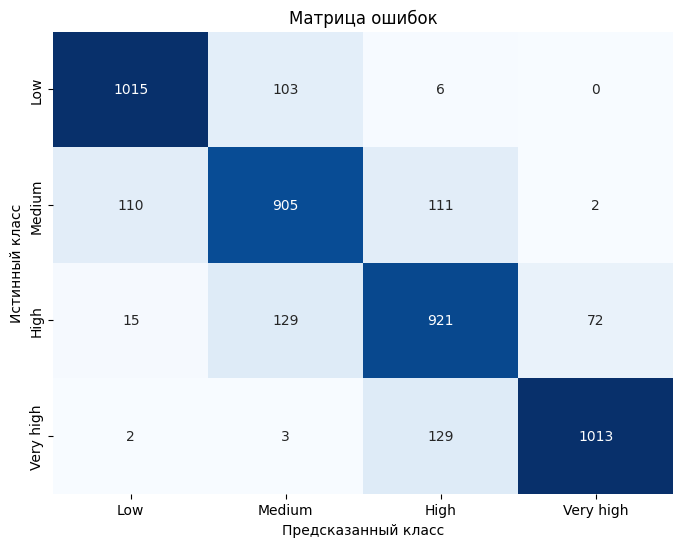

In [351]:
plot_confusion_matrix(y_test_cls_base, y_test_pred_cls_base)

**Точность модели (Accuracy)** на валидационной выборке составляет 62.91%, что является достаточно хорошим результатом при предсказании одного из 4 классов.

In [352]:

null_accuracy_base = (y_test_cls_base.value_counts().max()/y_test_cls_base.value_counts().sum())
print('Null accuracy score: {0:0.4f}'. format(null_accuracy_base))

Null accuracy score: 0.2529


### *Регрессия*

#### **a. Обучение модели из sklearn для выбранного набора данных**

In [353]:
X_regression_base = df_beer_base.drop(["review_overall"], axis=1)
y_regression_base = df_beer_base["review_overall"]
X_train_reg_base, X_test_reg_base, y_train_reg_base, y_test_reg_base = train_test_split(
    X_regression_base, y_regression_base, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_reg_scaled_base = scaler.fit_transform(X_train_reg_base)
X_test_reg_scaled_base = scaler.transform(X_test_reg_base)

knn_regressor = KNeighborsRegressor(n_neighbors=3)
knn_regressor.fit(X_train_reg_scaled_base, y_train_reg_base)

KNeighborsRegressor(n_neighbors=3)

#### **b. Оценка качества модели по выбранным метрикам на выбранном наборе данных**

In [354]:
y_test_pred_reg_base = knn_regressor.predict(X_test_reg_scaled_base)
y_train_pred_reg_base = knn_regressor.predict(X_train_reg_scaled_base)

# Вывод результатов
evaluate_regression(y_test_reg_base, y_test_pred_reg_base, 'Оценка на валидационной выборке:')

print()

evaluate_regression(y_train_reg_base, y_train_pred_reg_base, 'Оценка на тренировочной выборке:')

Оценка на валидационной выборке:
MAE = 0.2709
MAPE = 7.5804%
MSE = 0.1314
RMSE = 0.3625

Оценка на тренировочной выборке:
MAE = 0.1853
MAPE = 5.2771%
MSE = 0.0623
RMSE = 0.2495


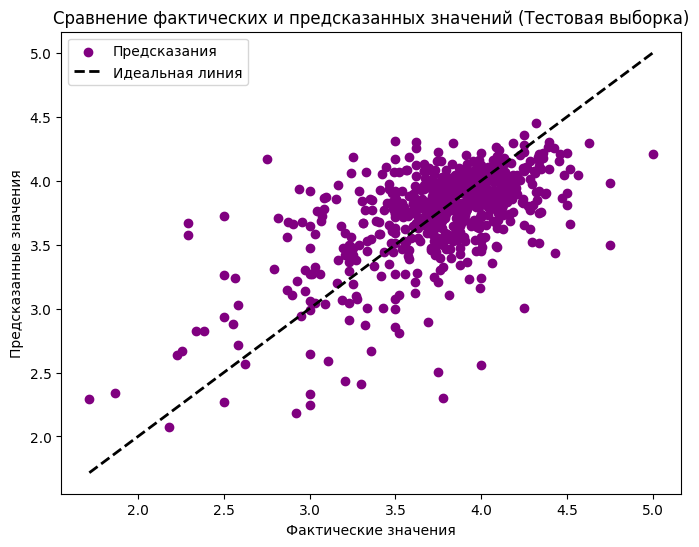

In [355]:
plot_scattering_diagram(y_test_reg_base, y_test_pred_reg_base)

## **3. Улучшение бейзлайна** и оценка

### **Улучшение бейзлайна**

In [356]:
df_beer_optimized = df_beer.copy()
df_flats_optimized = df_flats.copy()

**a. b. c. Формирование гипотез и их проверка, а также формирование улучшенного бейзлайна по результатам проверки гипотез (препроцессинг данных, визуализация данных, формирование новых признаков, подбор гиперпараметров на кросс-валидации)**

**Препроцессинг данных**

In [357]:
df_beer_optimized.isna().sum()

Style                0
Brewery              0
Beer Name (Full)     0
ABV                  0
Min IBU              0
Max IBU              0
Astringency          0
Body                 0
Alcohol              0
Bitter               0
Sweet                0
Sour                 0
Salty                0
Fruits               0
Hoppy                0
Spices               0
Malty                0
review_overall       0
number_of_reviews    0
dtype: int64

In [358]:
df_beer_optimized[df_beer_optimized.duplicated()]

,Style,Brewery,Beer Name (Full),ABV,Min IBU,Max IBU,Astringency,Body,Alcohol,Bitter,Sweet,Sour,Salty,Fruits,Hoppy,Spices,Malty,review_overall,number_of_reviews


In [359]:
df_beer_optimized.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3197 entries, 0 to 3196
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Style              3197 non-null   int64  
 1   Brewery            3197 non-null   int64  
 2   Beer Name (Full)   3197 non-null   int64  
 3   ABV                3197 non-null   float64
 4   Min IBU            3197 non-null   int64  
 5   Max IBU            3197 non-null   int64  
 6   Astringency        3197 non-null   int64  
 7   Body               3197 non-null   int64  
 8   Alcohol            3197 non-null   int64  
 9   Bitter             3197 non-null   int64  
 10  Sweet              3197 non-null   int64  
 11  Sour               3197 non-null   int64  
 12  Salty              3197 non-null   int64  
 13  Fruits             3197 non-null   int64  
 14  Hoppy              3197 non-null   int64  
 15  Spices             3197 non-null   int64  
 16  Malty              3197 

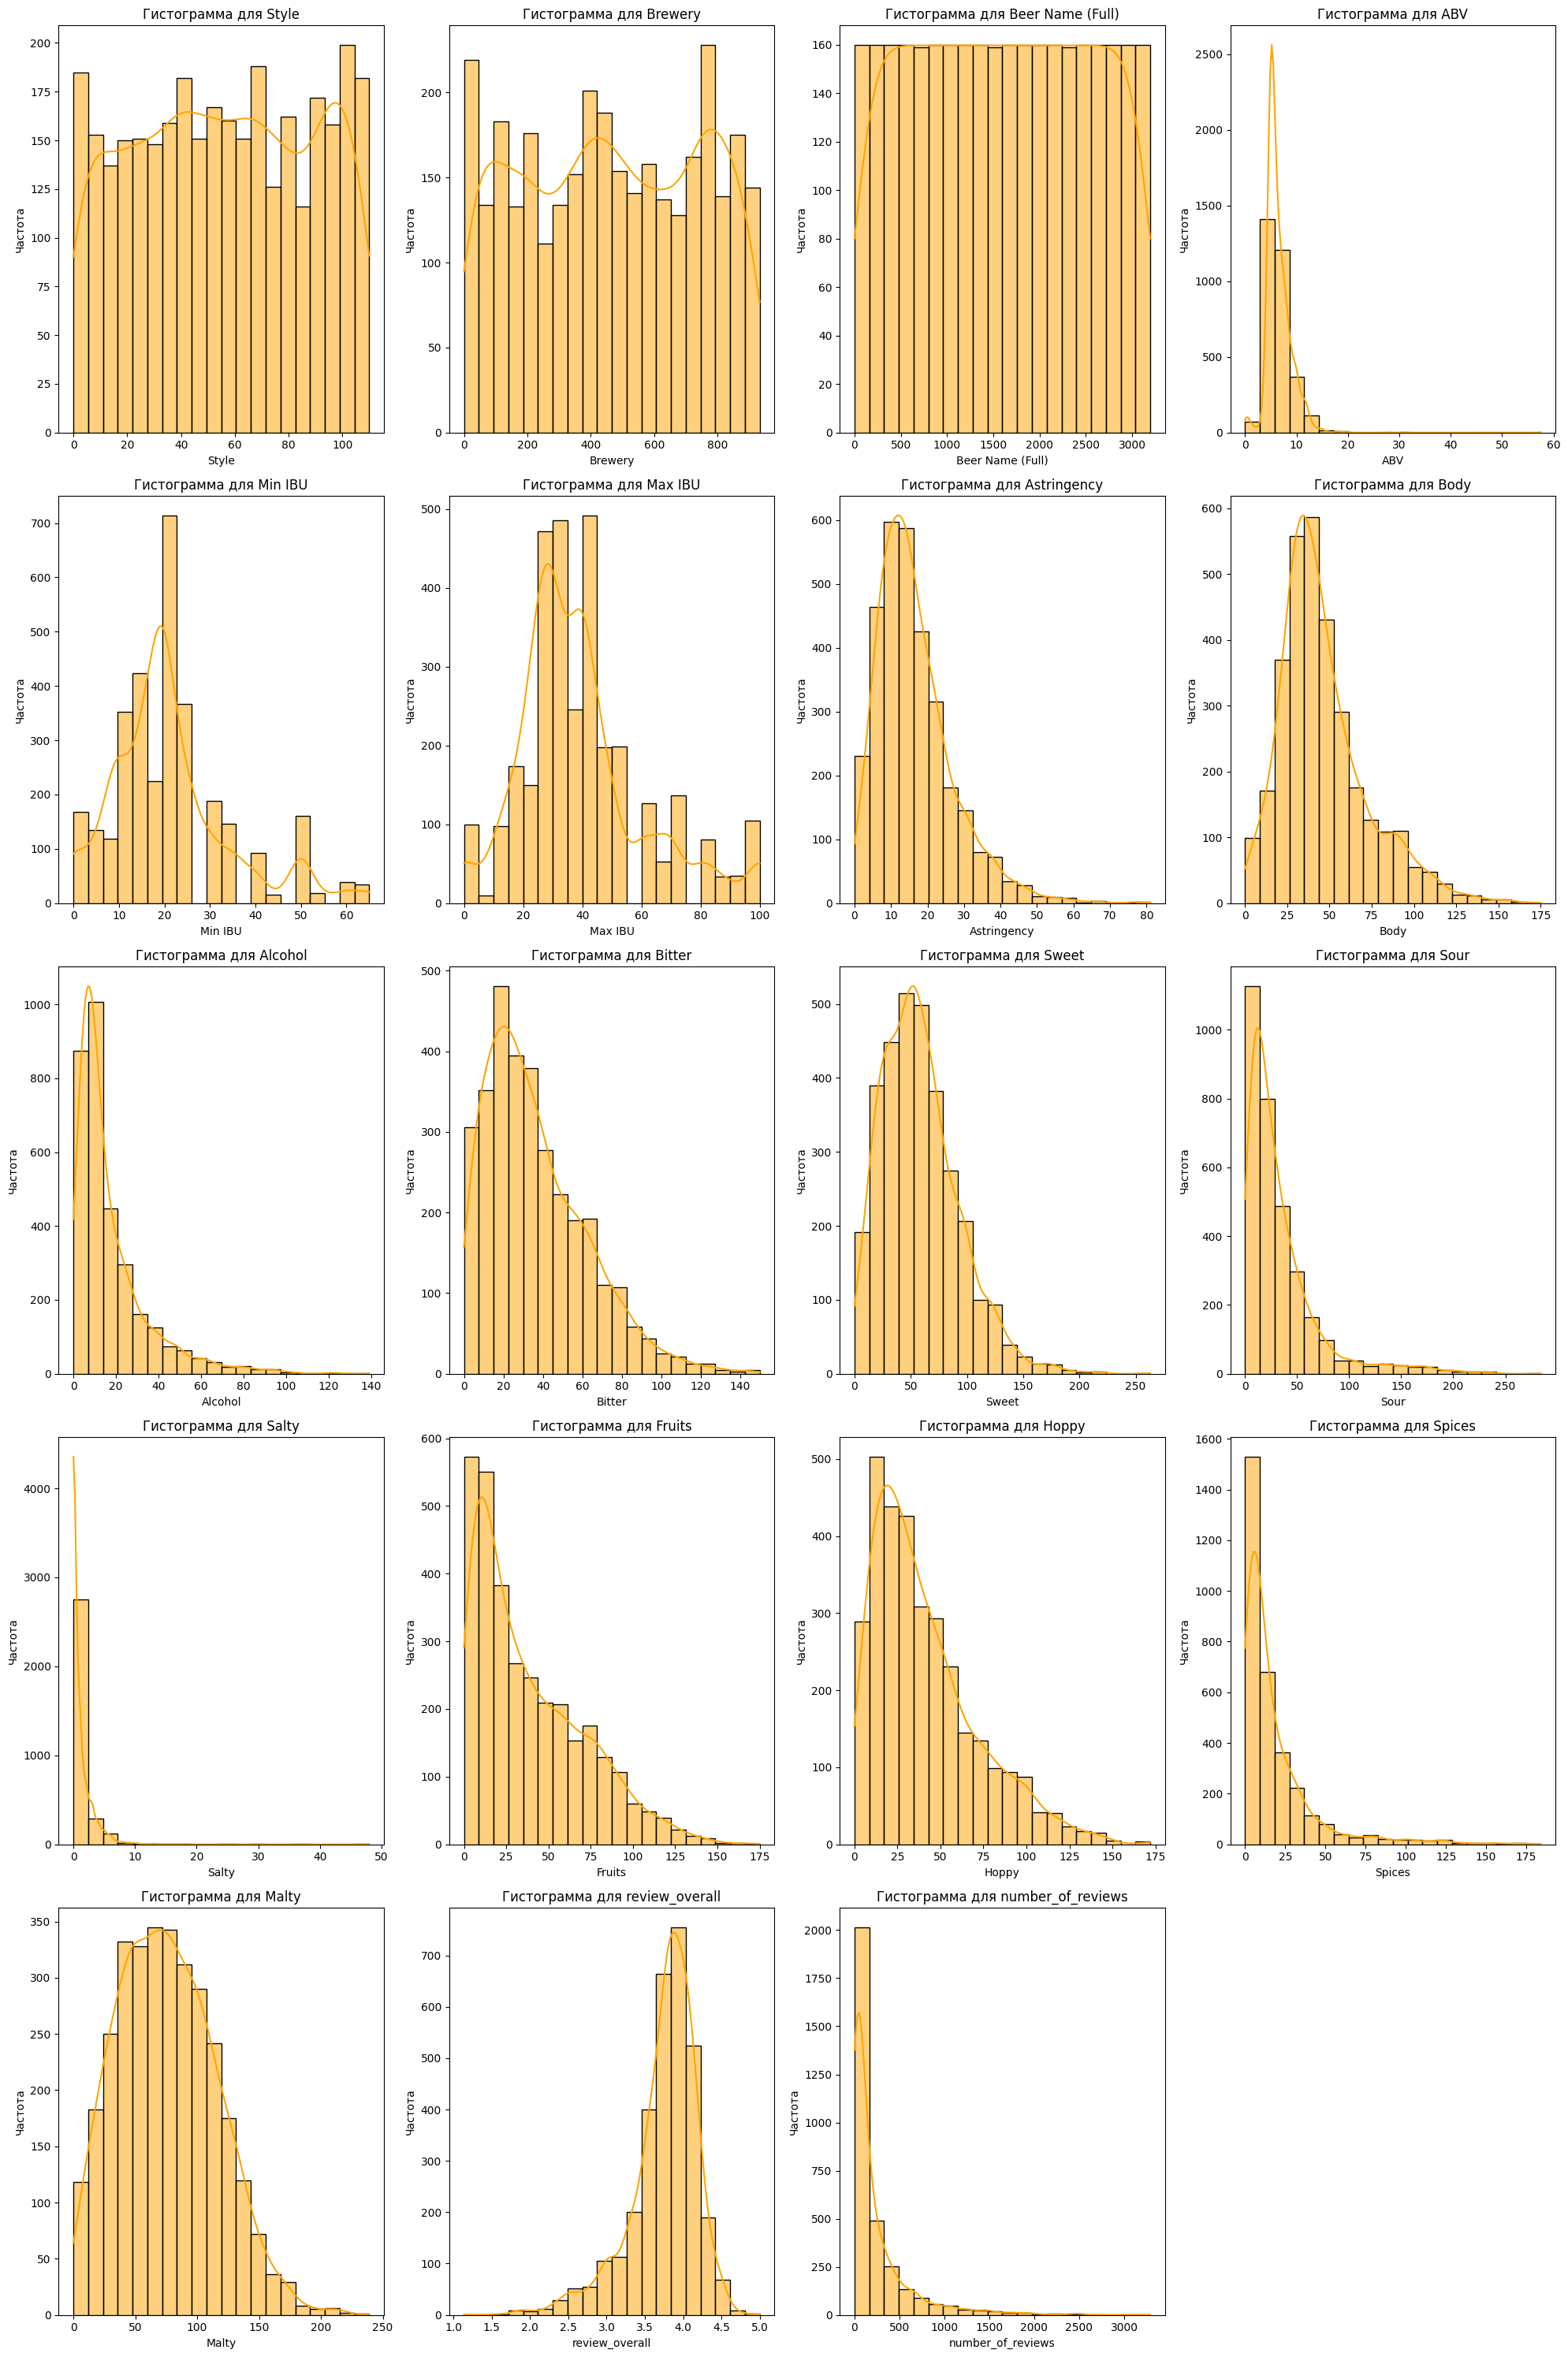

In [360]:
import matplotlib.pyplot as plt

numerical_columns = df_beer_optimized.select_dtypes(include=['number']).columns

n_cols = 4
n_rows = (len(numerical_columns) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 6))
axes = axes.flatten()

for idx, col in enumerate(numerical_columns):
    sns.histplot(df_beer_optimized[col], kde=True, ax=axes[idx], color='orange', bins=20)
    axes[idx].set_title(f'Гистограмма для {col}')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Частота')

for i in range(len(numerical_columns), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()

plt.show()


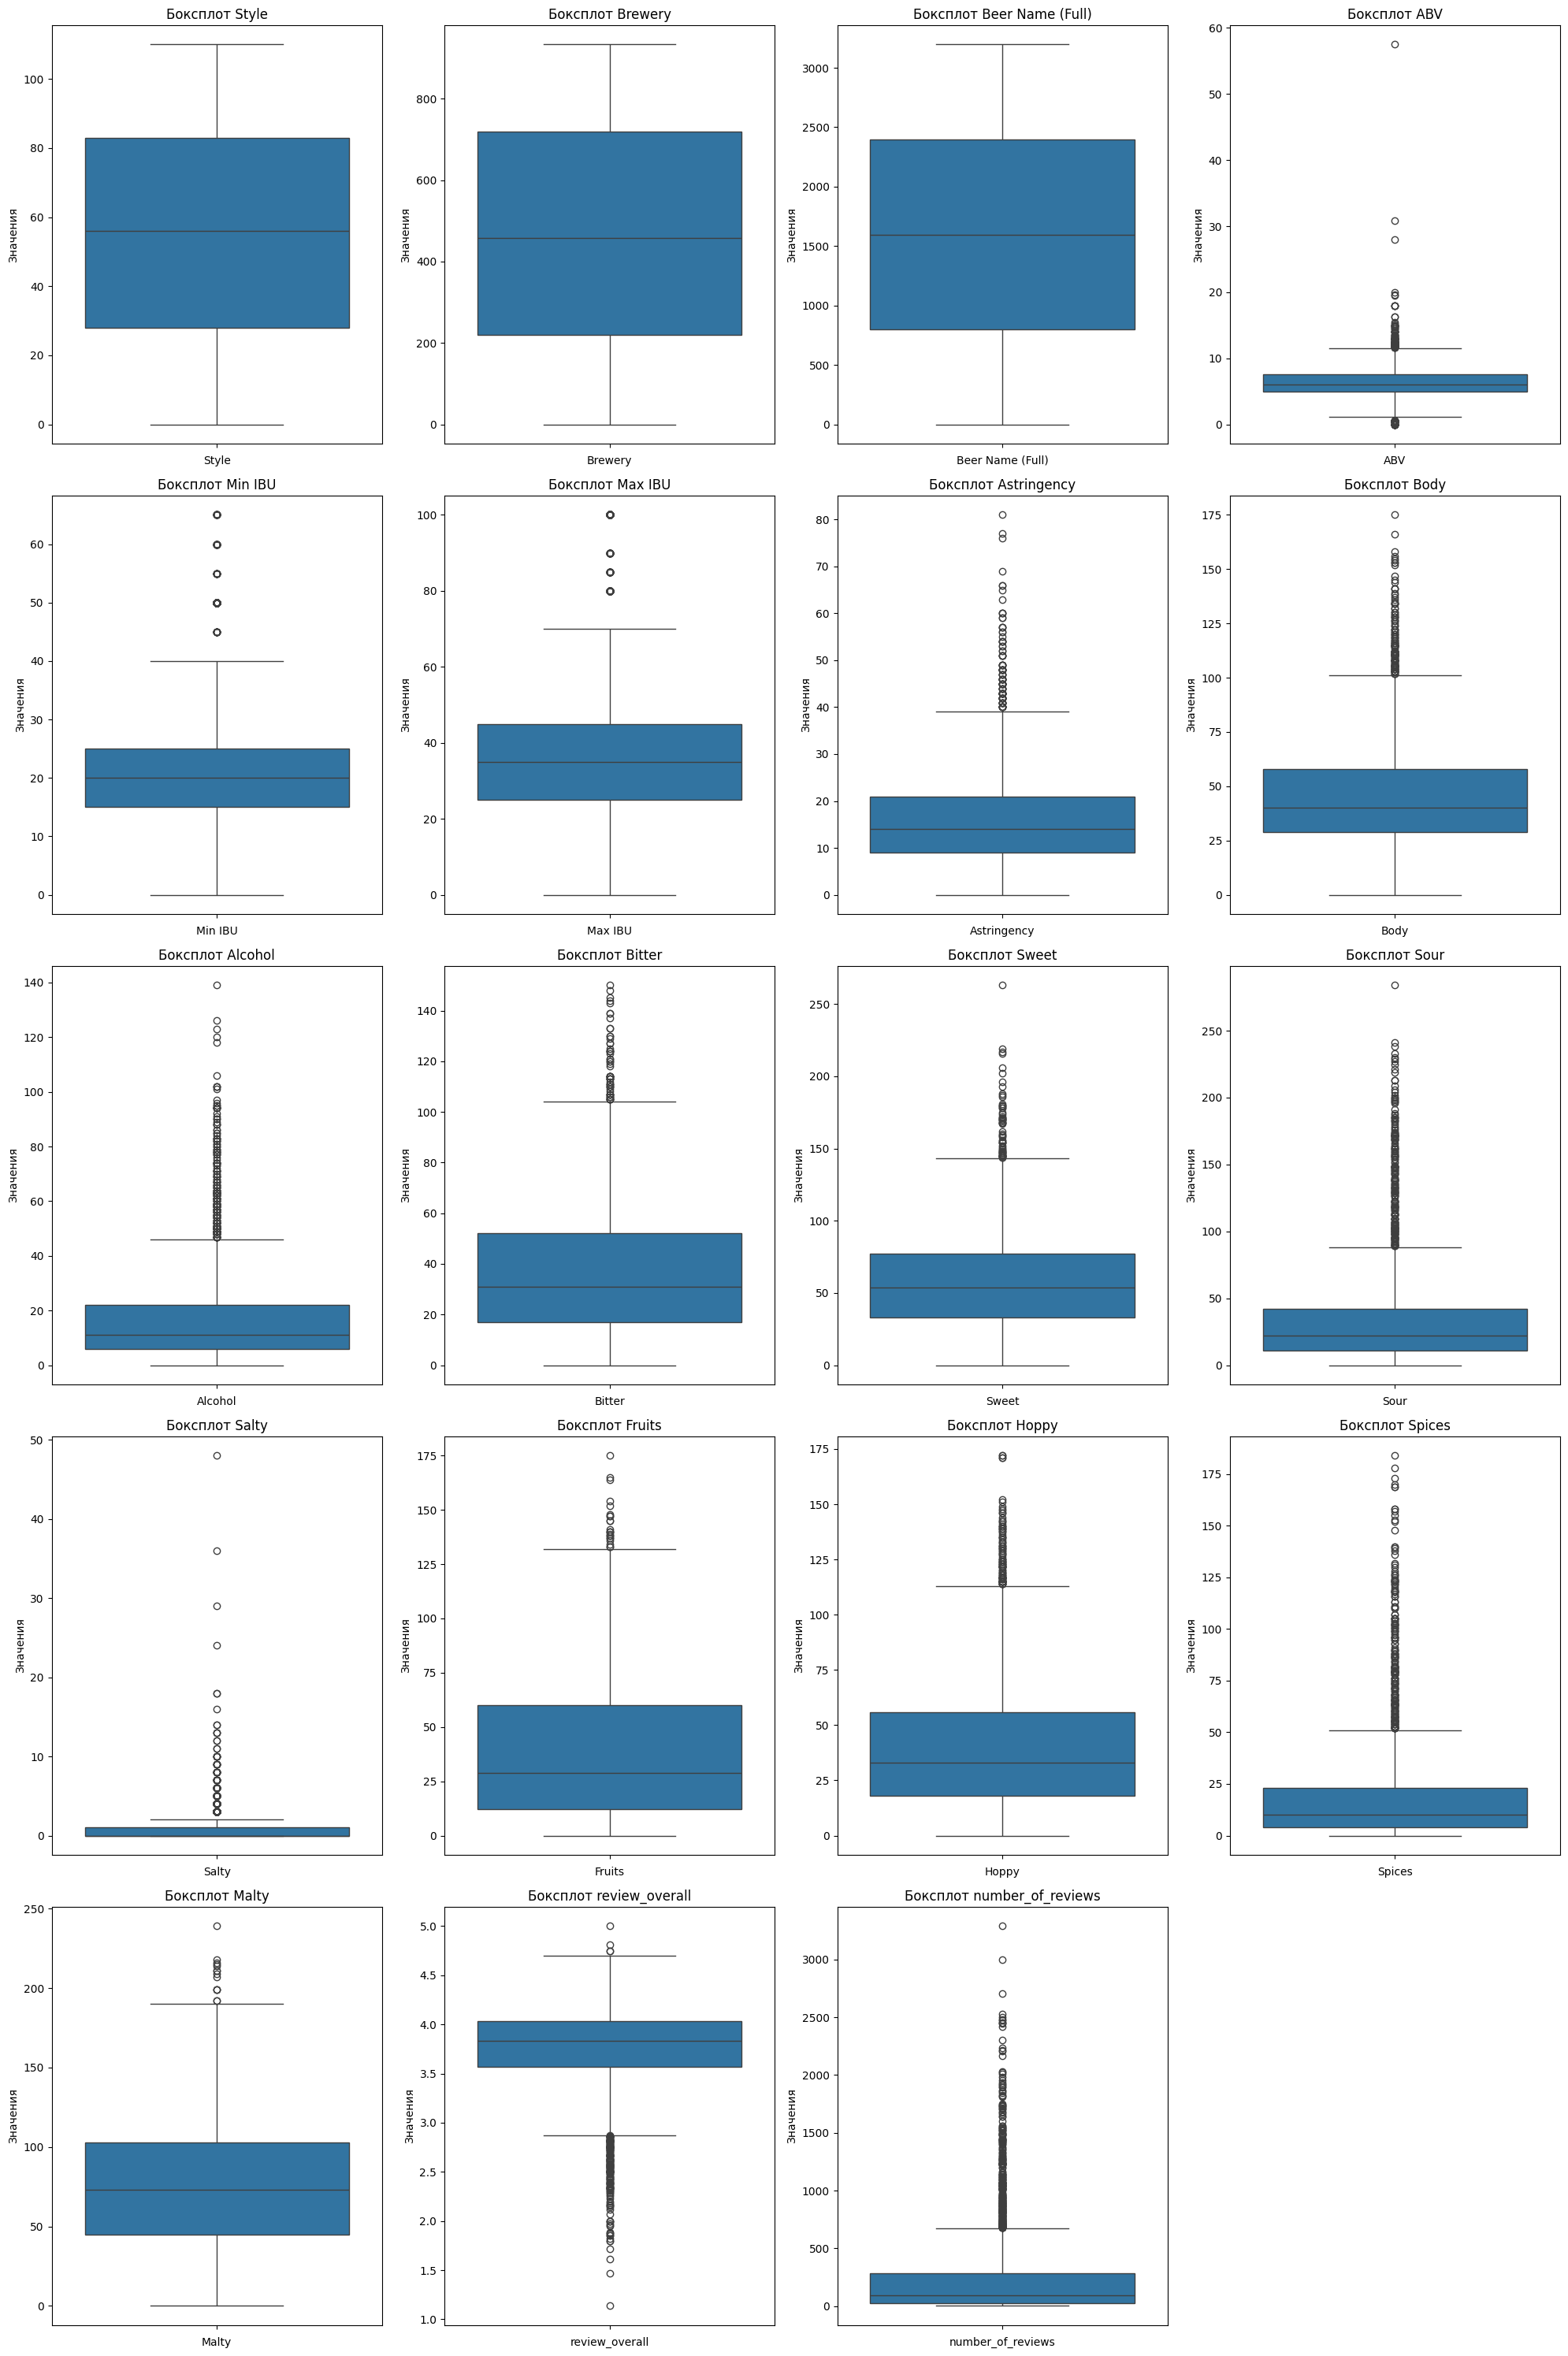

In [361]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 6))
axes = axes.flatten()

numerical_columns = df_beer_optimized.select_dtypes(include=['number']).columns


for idx, col in enumerate(numerical_columns):
    sns.boxplot(y=df_beer_optimized[col], ax=axes[idx])
    axes[idx].set_title(f'Боксплот {col}')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Значения')

for i in range(len(numerical_columns), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

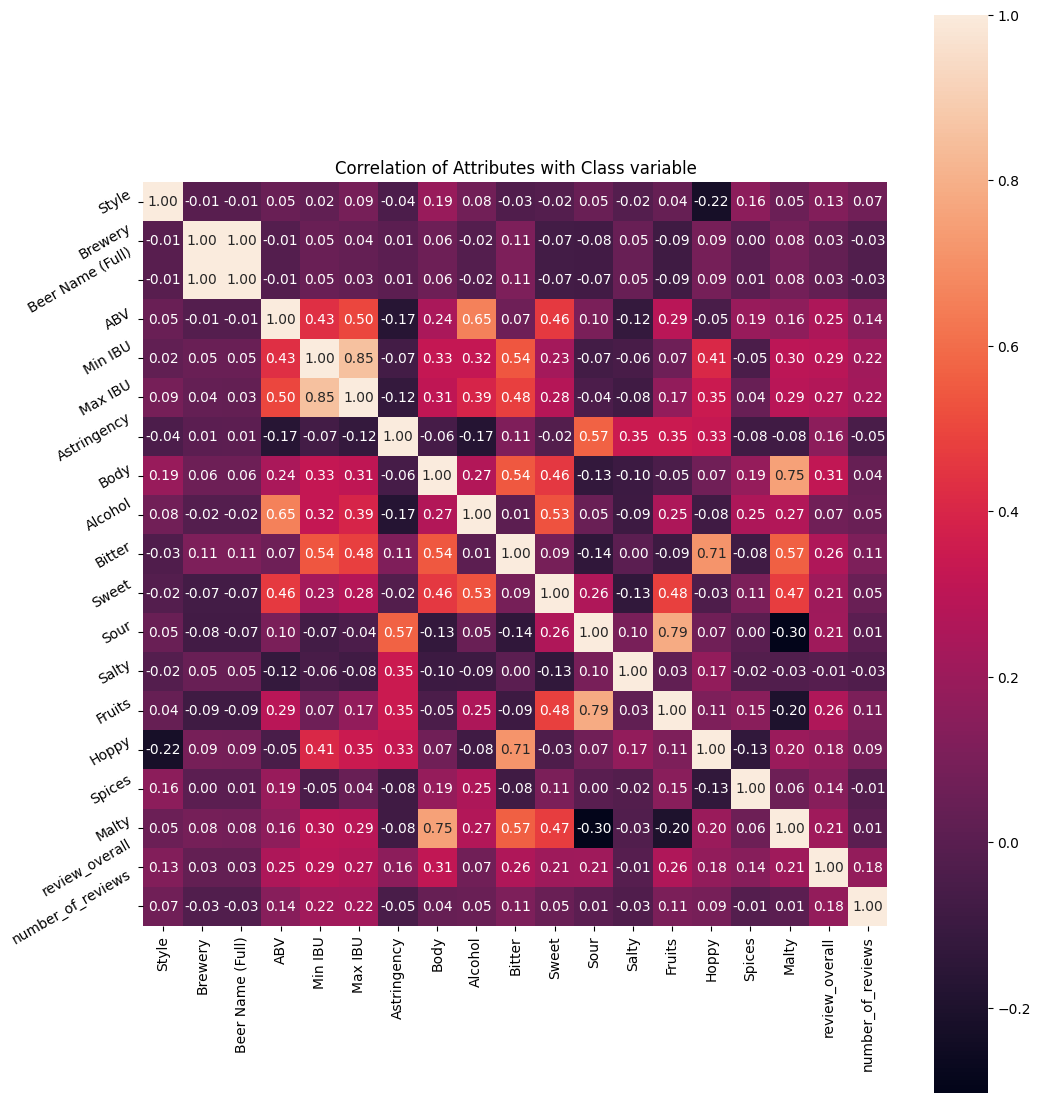

In [362]:
df_beer_temp = df_beer_optimized.copy(deep=True)

label_encoder = LabelEncoder()

correlation = df_beer_temp.corr()

plt.figure(figsize=(12,14))
plt.title('Correlation of Attributes with Class variable')
a = sns.heatmap(correlation, square=True, annot=True, fmt='.2f', linecolor='white')
a.set_xticklabels(a.get_xticklabels(), rotation=90)
a.set_yticklabels(a.get_yticklabels(), rotation=30)
plt.show()


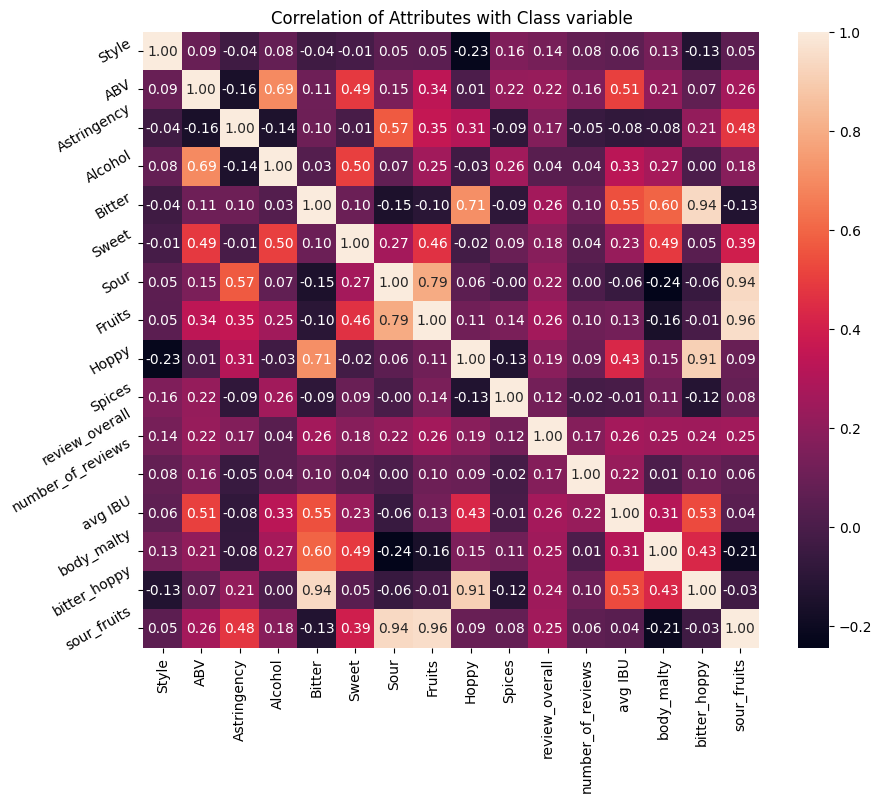

In [363]:

Q1 = df_beer_temp['ABV'].quantile(0.25)
Q3 = df_beer_temp['ABV'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_beer_temp = df_beer_temp[(df_beer_temp['ABV'] >= lower_bound) & (df_beer_temp['ABV'] <= upper_bound)]


weights_ibu = [0.52, 0.48]  # Большее значение для Min IBU
weights_body_malty = [0.6, 0.4]  # Равный вклад
weights_bitter_hoppy = [0.59, 0.41]  # Большее значение для Bitter
weights_sour_fruits = [0.43, 0.57]  # Большее значение для Fruits

df_beer_temp['avg IBU'] = df_beer_temp[['Min IBU', 'Max IBU']].apply(
    lambda row: np.average(row, weights=weights_ibu), axis=1)
df_beer_temp['body_malty'] = df_beer_temp[['Body', 'Malty']].apply(
    lambda row: np.average(row, weights=weights_body_malty), axis=1)
df_beer_temp['bitter_hoppy'] = df_beer_temp[['Bitter', 'Hoppy']].apply(
    lambda row: np.average(row, weights=weights_bitter_hoppy), axis=1)
df_beer_temp['sour_fruits'] = df_beer_temp[['Sour', 'Fruits']].apply(
    lambda row: np.average(row, weights=weights_sour_fruits), axis=1)

df_beer_temp = df_beer_temp.drop(columns=['Beer Name (Full)', 'Salty', 'Brewery', 'Min IBU', 'Max IBU', 'Body', 'Malty'])

weight_boost = 2
df_beer_temp['avg IBU'] *= weight_boost
df_beer_temp['sour_fruits'] *= weight_boost
df_beer_temp['ABV'] *= weight_boost

correlation = df_beer_temp.corr()

plt.figure(figsize=(10,8))
plt.title('Correlation of Attributes with Class variable')
a = sns.heatmap(correlation, square=True, annot=True, fmt='.2f', linecolor='white')
a.set_xticklabels(a.get_xticklabels(), rotation=90)
a.set_yticklabels(a.get_yticklabels(), rotation=30)
plt.show()

In [364]:
df_flats_optimized.isna().sum()

Price                                   0
Apartment type                          0
Metro station                           0
Minutes to metro                        0
Region                                  0
Number of rooms                         0
Area                                    0
Living area                             0
Kitchen area                            0
Floor                                   0
Number of floors                        0
Renovation_Designer                     0
Renovation_European-style renovation    0
Renovation_Without renovation           0
Price Category                          0
dtype: int64

In [365]:
df_flats_optimized[df_flats_optimized.duplicated()]

,Price,Apartment type,Metro station,Minutes to metro,Region,Number of rooms,Area,Living area,Kitchen area,Floor,Number of floors,Renovation_Designer,Renovation_European-style renovation,Renovation_Without renovation,Price Category
354,179000000.0,1,201,11.0,0,3.0,141.00,73.4,18.3,3.0,15,True,False,False,Very high
628,120000000.0,1,11,12.0,0,4.0,136.50,94.7,7.3,23.0,41,True,False,False,Very high
983,289000000.0,1,86,10.0,0,6.0,301.50,178.3,16.7,2.0,3,True,False,False,Very high
1002,9727384.0,1,143,7.0,1,1.0,42.40,23.6,10.1,6.0,6,False,False,False,Medium
1014,10534383.0,1,143,7.0,1,1.0,40.80,22.8,10.0,3.0,6,False,False,False,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22637,5938187.0,0,351,8.0,1,1.0,43.94,17.6,11.8,10.0,17,False,False,False,Low
22661,6692525.0,0,351,8.0,1,2.0,54.31,32.3,5.0,8.0,17,False,False,False,Low
22665,4755584.0,0,351,8.0,1,0.0,31.66,12.9,5.0,4.0,17,False,False,False,Low
22669,5954269.0,0,351,8.0,1,1.0,43.94,17.6,11.8,11.0,17,False,False,False,Low


In [366]:
df_flats_optimized.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22676 entries, 0 to 22675
Data columns (total 15 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Price                                 22676 non-null  float64
 1   Apartment type                        22676 non-null  int64  
 2   Metro station                         22676 non-null  int64  
 3   Minutes to metro                      22676 non-null  float64
 4   Region                                22676 non-null  int64  
 5   Number of rooms                       22676 non-null  float64
 6   Area                                  22676 non-null  float64
 7   Living area                           22676 non-null  float64
 8   Kitchen area                          22676 non-null  float64
 9   Floor                                 22676 non-null  float64
 10  Number of floors                      22676 non-null  int64  
 11  Renovation_Desi

**Визуализация данных**

Посмотрим на распределения у фичей

Посмотрим на наличие выбросов

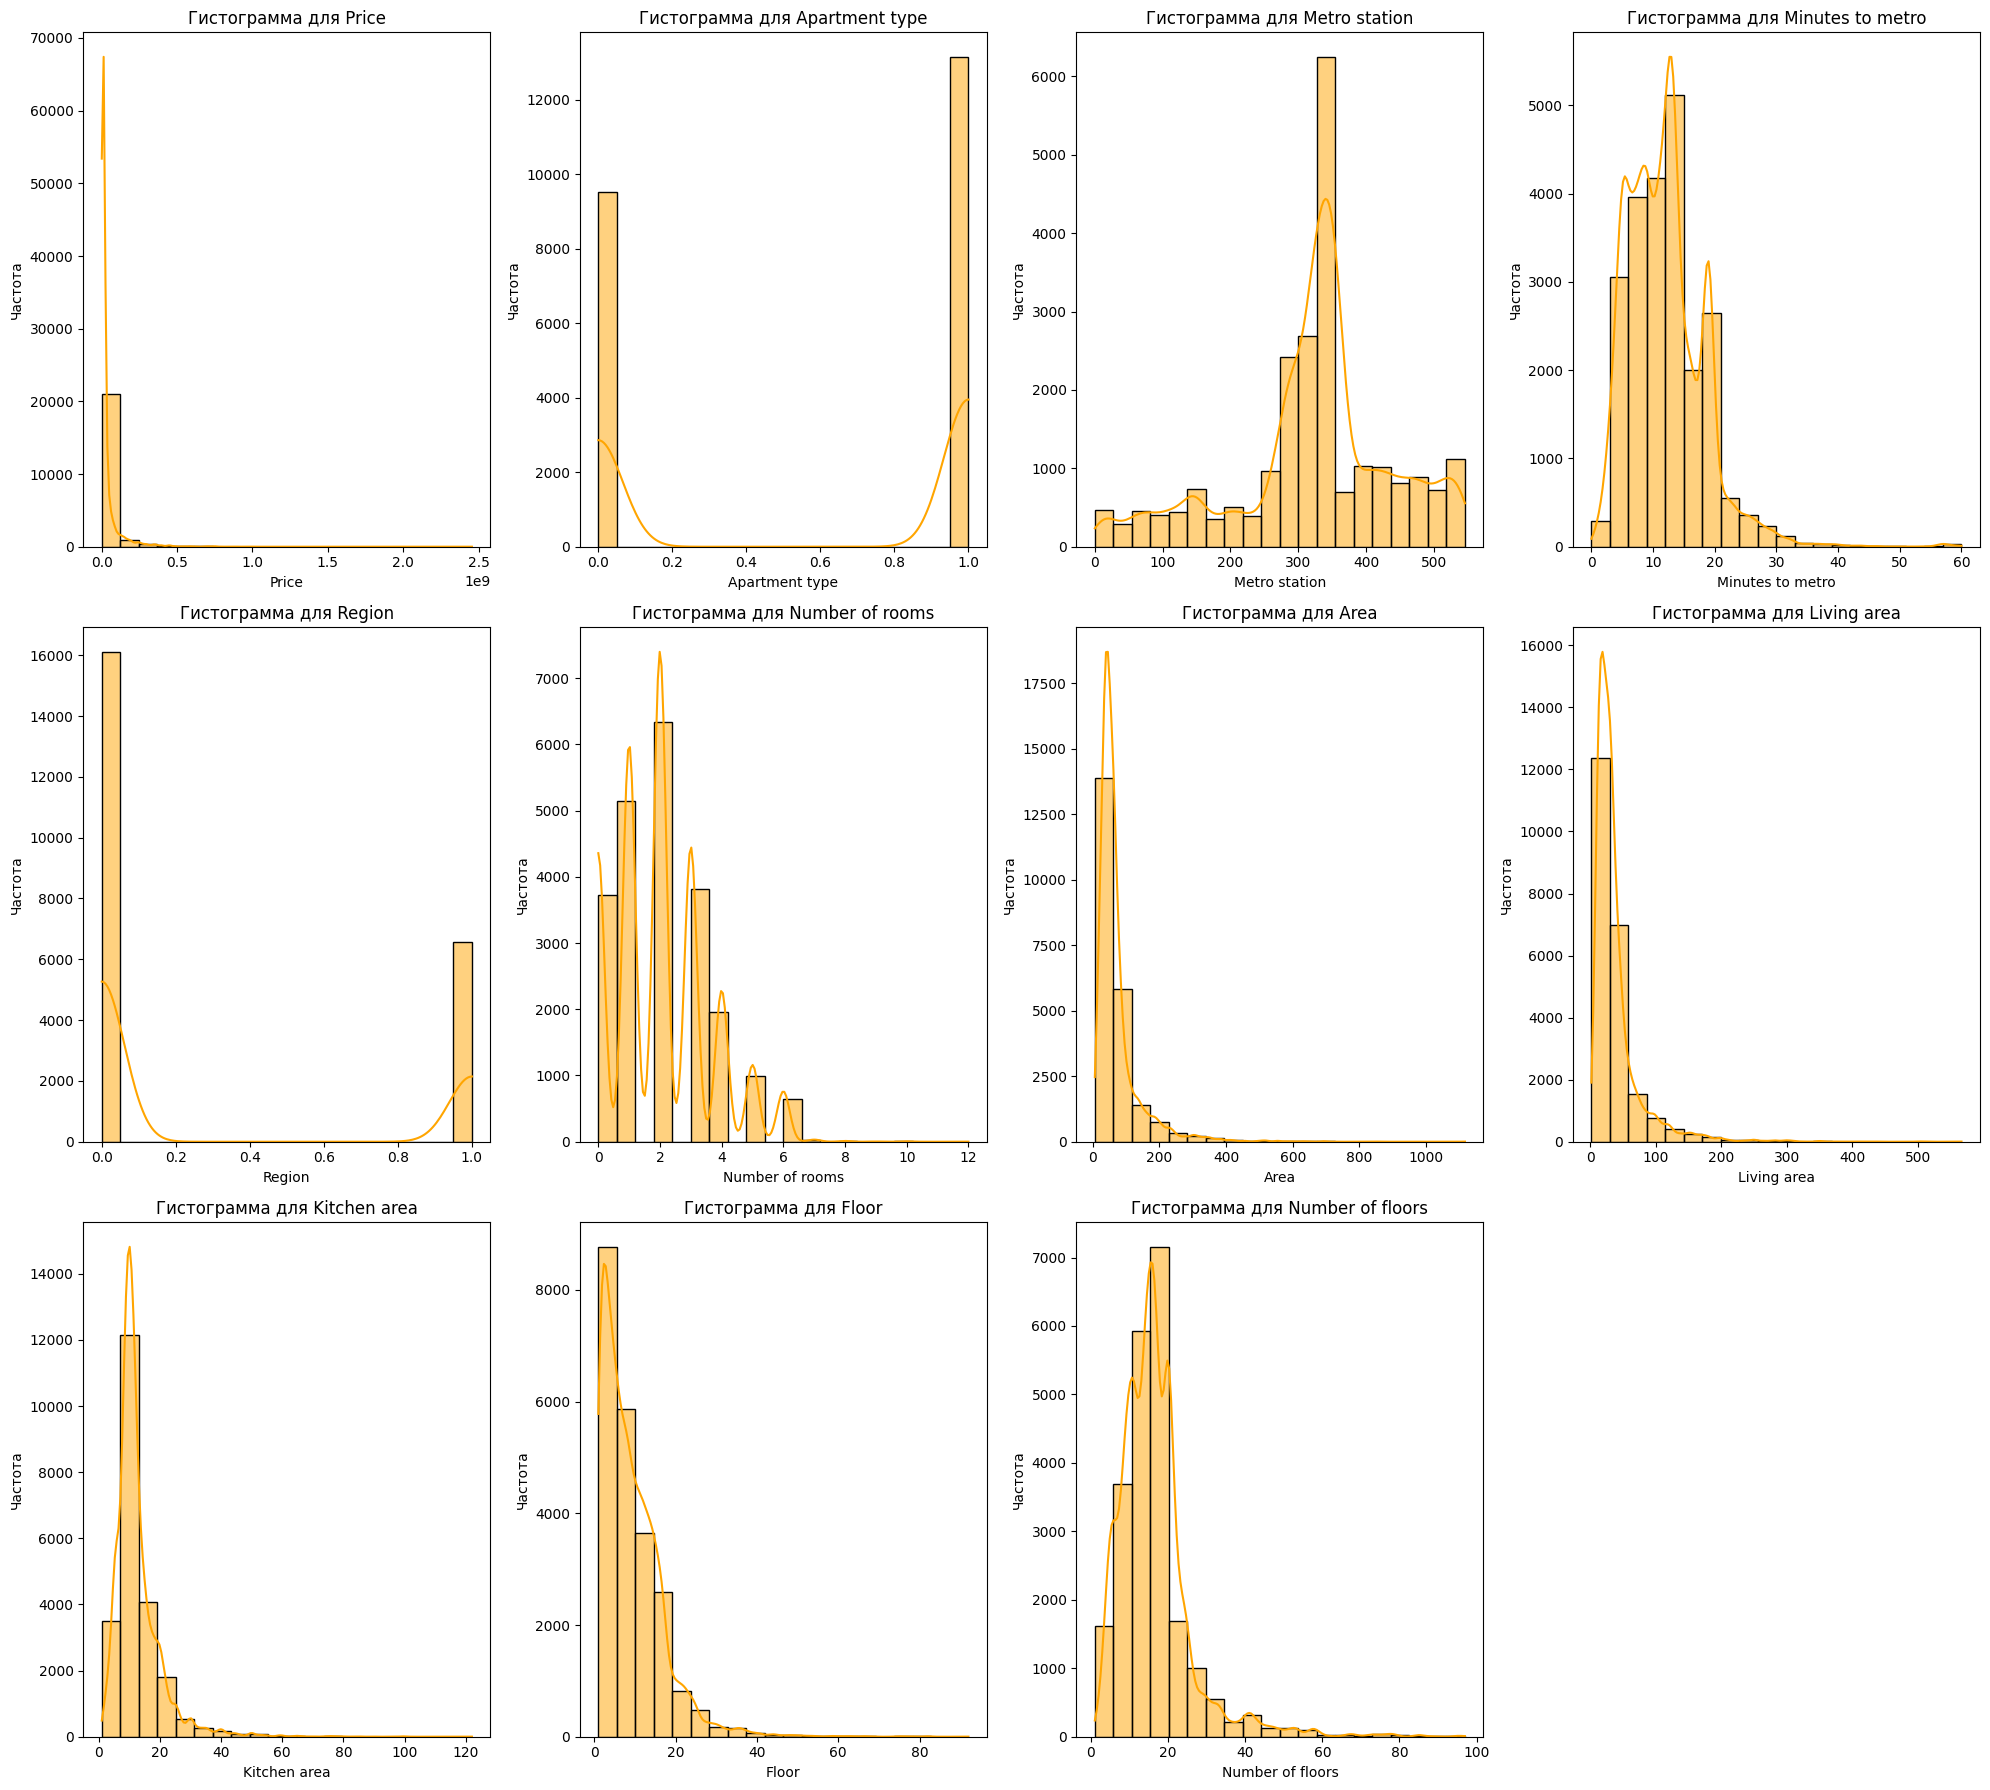

In [367]:
import matplotlib.pyplot as plt
import seaborn as sns

numerical_columns = df_flats_optimized.select_dtypes(include=['number']).columns

n_cols = 4
n_rows = (len(numerical_columns) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 6))
axes = axes.flatten()

for idx, col in enumerate(numerical_columns):
    sns.histplot(df_flats_optimized[col], kde=True, ax=axes[idx], color='orange', bins=20)
    axes[idx].set_title(f'Гистограмма для {col}')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Частота')

for i in range(len(numerical_columns), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()


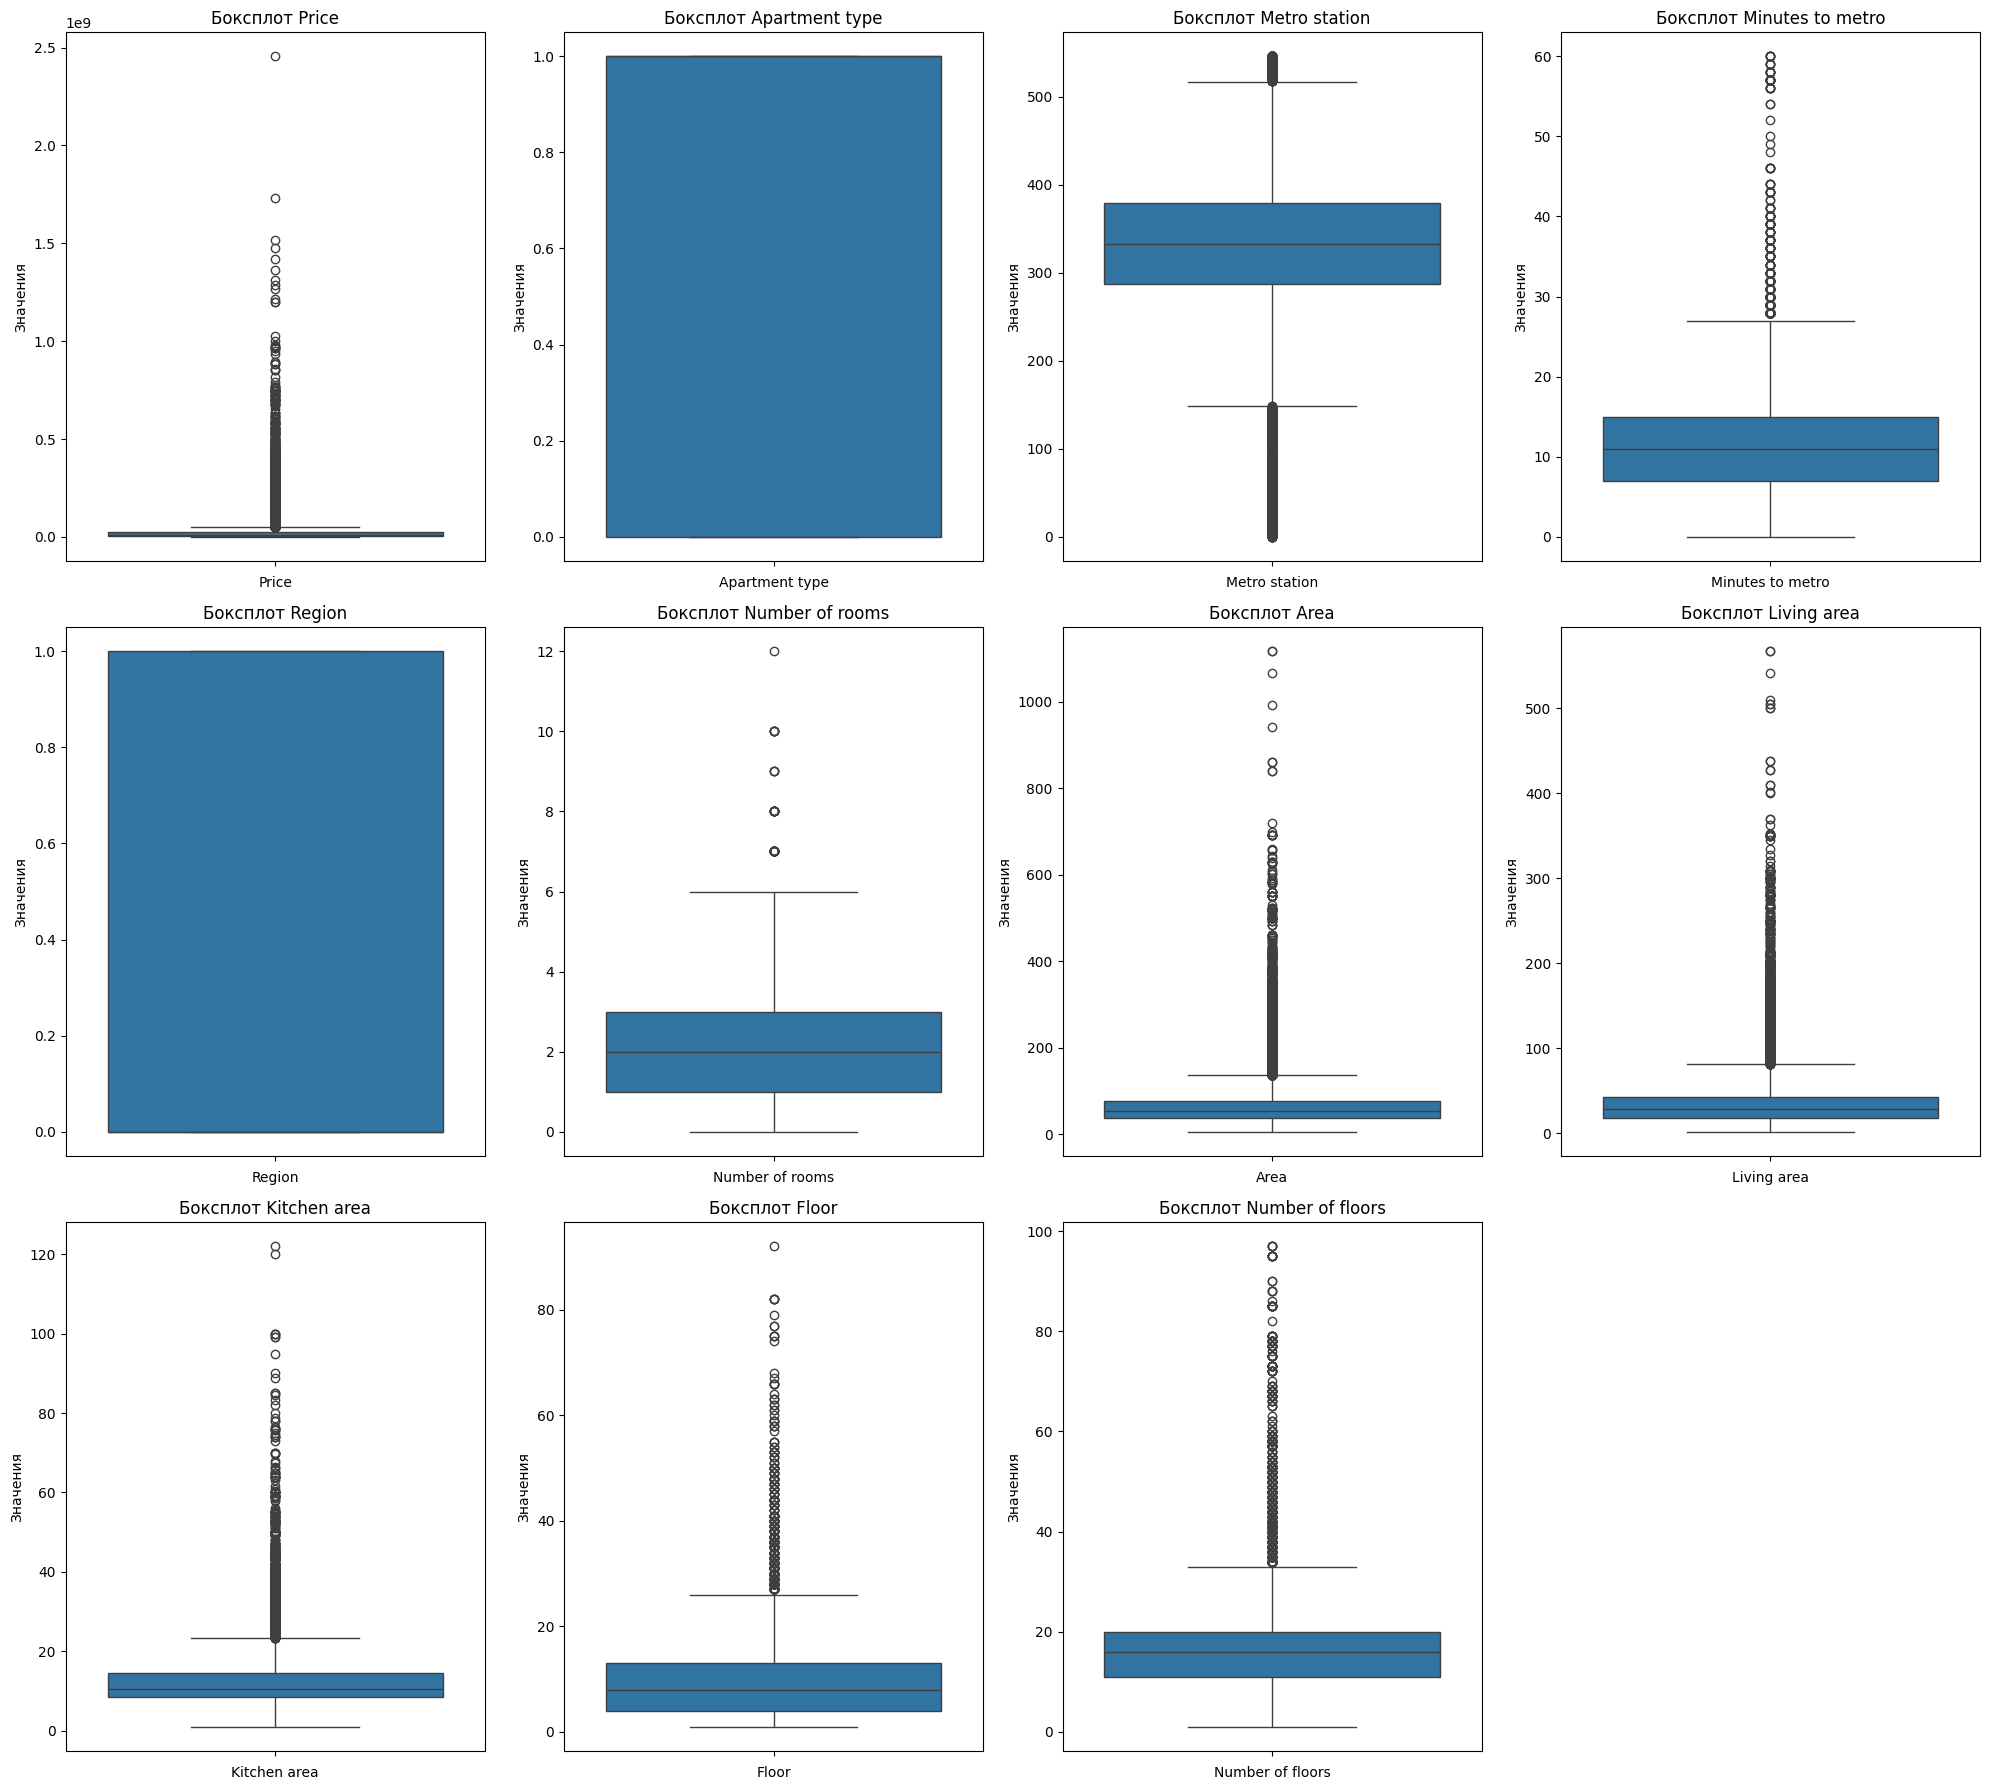

In [368]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 6))
axes = axes.flatten()

numerical_columns = df_flats_optimized.select_dtypes(include=['number']).columns


for idx, col in enumerate(numerical_columns):
    sns.boxplot(y=df_flats_optimized[col], ax=axes[idx])
    axes[idx].set_title(f'Боксплот {col}')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Значения')

for i in range(len(numerical_columns), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

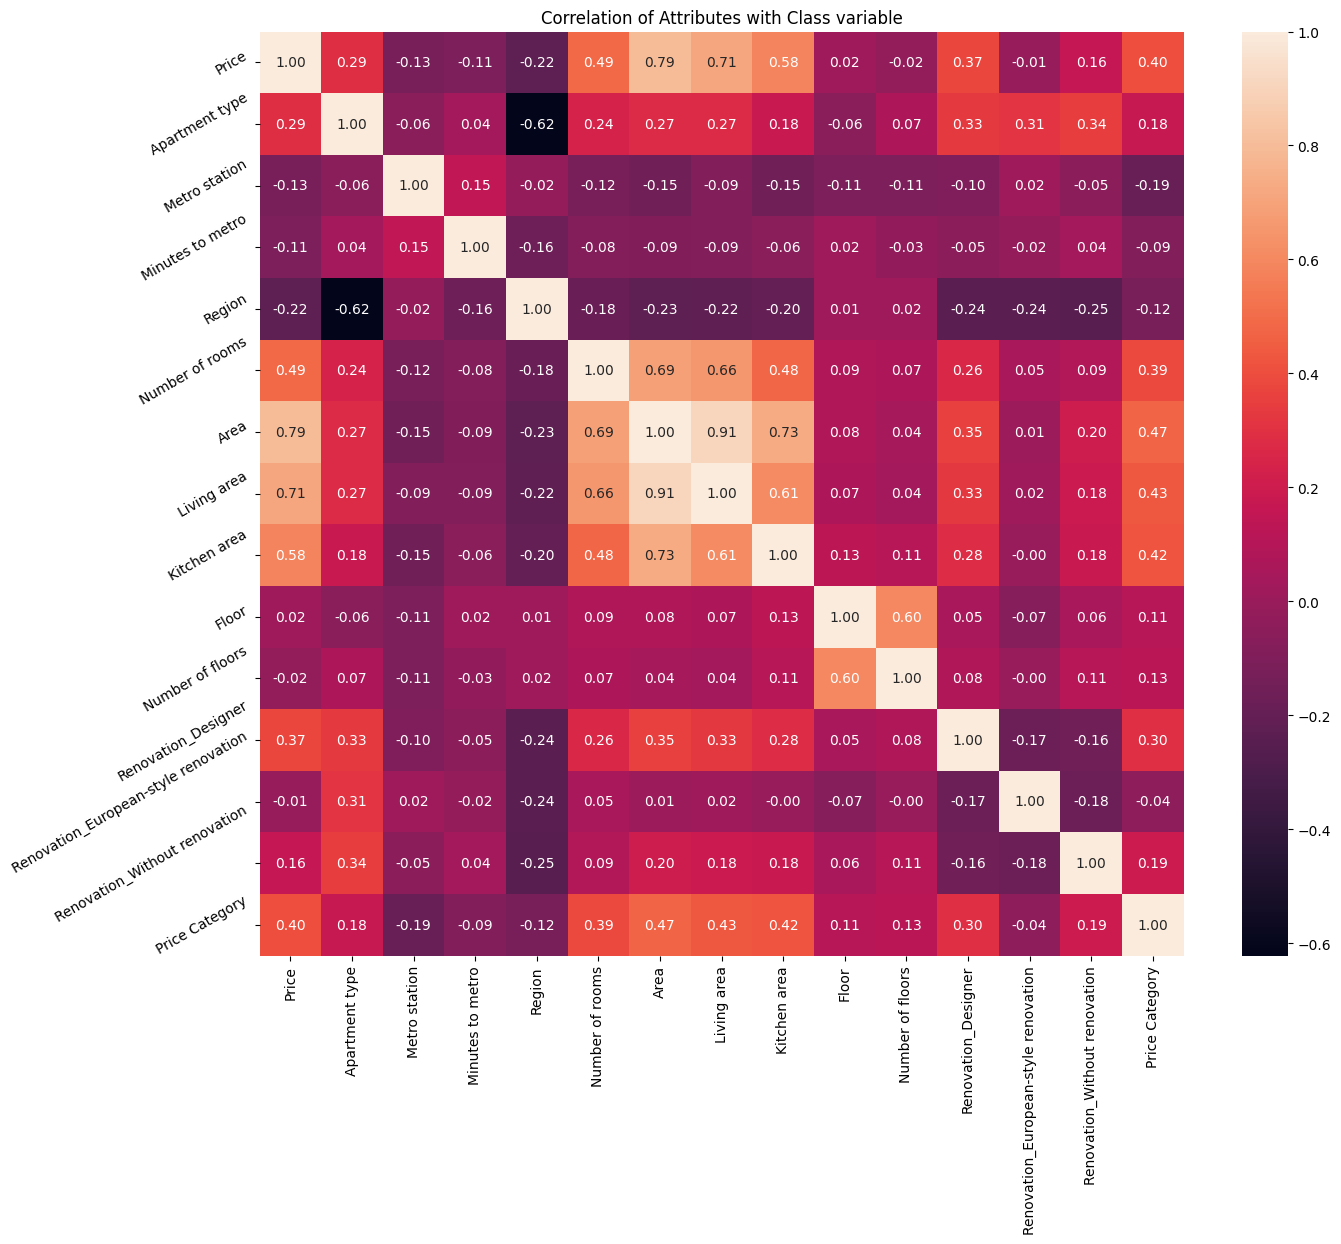

In [369]:
df_flats_temp = df_flats_optimized.copy(deep=True)

label_encoder = LabelEncoder()

df_flats_temp['Price Category'] = label_encoder.fit_transform(df_flats_temp['Price Category'])

correlation = df_flats_temp.corr()

plt.figure(figsize=(15,12))
plt.title('Correlation of Attributes with Class variable')
a = sns.heatmap(correlation, square=True, annot=True, fmt='.2f', linecolor='white')
a.set_xticklabels(a.get_xticklabels(), rotation=90)
a.set_yticklabels(a.get_yticklabels(), rotation=30)
plt.show()


In [370]:
df_flats_temp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22676 entries, 0 to 22675
Data columns (total 15 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Price                                 22676 non-null  float64
 1   Apartment type                        22676 non-null  int64  
 2   Metro station                         22676 non-null  int64  
 3   Minutes to metro                      22676 non-null  float64
 4   Region                                22676 non-null  int64  
 5   Number of rooms                       22676 non-null  float64
 6   Area                                  22676 non-null  float64
 7   Living area                           22676 non-null  float64
 8   Kitchen area                          22676 non-null  float64
 9   Floor                                 22676 non-null  float64
 10  Number of floors                      22676 non-null  int64  
 11  Renovation_Desi

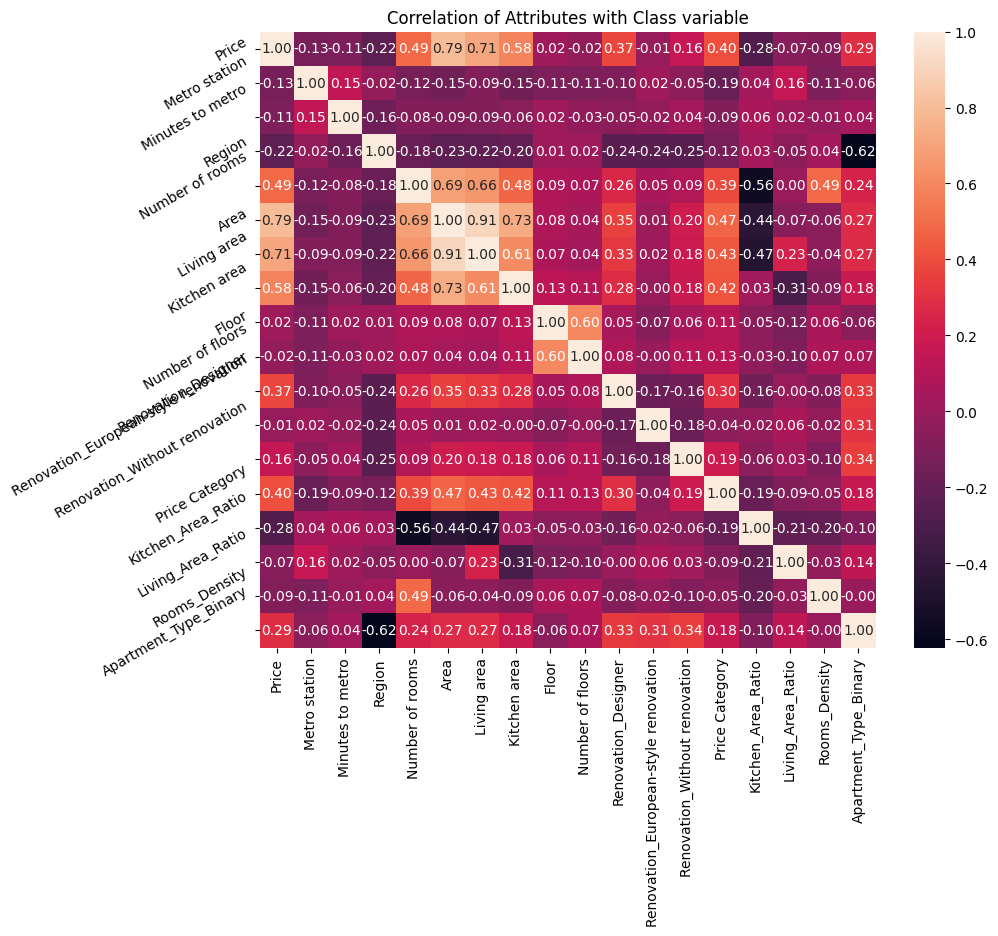

In [371]:
df_flats_temp['Kitchen_Area_Ratio'] = df_flats_temp['Kitchen area'] / df_flats_temp['Area']
df_flats_temp['Living_Area_Ratio'] = df_flats_temp['Living area'] / df_flats_temp['Area']
df_flats_temp['Rooms_Density'] = df_flats_temp['Number of rooms'] / df_flats_temp['Area']
df_flats_temp['Apartment_Type_Binary'] = (df_flats_temp['Apartment type'] == df_flats_temp['Apartment type'].max()).astype(int)
df_flats_temp = df_flats_temp.drop(columns=['Apartment type'])

correlation = df_flats_temp.corr()

plt.figure(figsize=(10,8))
plt.title('Correlation of Attributes with Class variable')
a = sns.heatmap(correlation, square=True, annot=True, fmt='.2f', linecolor='white')
a.set_xticklabels(a.get_xticklabels(), rotation=90)
a.set_yticklabels(a.get_yticklabels(), rotation=30)
plt.show()

### *Классификация*

**d. Обучение модели с улучшенным бейзлайном на выбранном наборе данных**

In [372]:
df_flats_temp['Price Category'] = label_encoder.inverse_transform(df_flats_temp['Price Category'])
df_flats_optimized = df_flats_temp

X_classification_optimized = df_flats_optimized.drop(columns=['Price', 'Price Category'], axis=1)
y_classification_optimized = df_flats_optimized['Price Category']

X_train_cls_optimized, X_test_cls_optimized, y_train_cls_optimized, y_test_cls_optimized = train_test_split(
    X_classification_optimized, y_classification_optimized, test_size=0.2, random_state=42
)

scaler = StandardScaler() 
X_train_cls_scaled_optimized  = scaler.fit_transform(X_train_cls_optimized)
X_test_cls_scaled_optimized  = scaler.transform(X_test_cls_optimized)

knn_classifier = KNeighborsClassifier(n_neighbors=11, weights='distance')
knn_classifier.fit(X_train_cls_scaled_optimized, y_train_cls_optimized)


KNeighborsClassifier(n_neighbors=11, weights='distance')

**e.	Оценка качества моделей с улучшенным бейзлайном по выбранным метрикам на выбранных наборах данных**

In [373]:
y_pred_train_cls_optimized = knn_classifier.predict(X_train_cls_scaled_optimized)
y_pred_test_cls_optimized = knn_classifier.predict(X_test_cls_scaled_optimized)

evaluate_classification(y_test_cls_optimized, y_pred_test_cls_optimized, 'Оценка на валидационной выборке:')

print()

evaluate_classification(y_train_cls_optimized, y_pred_train_cls_optimized, 'Оценка на тренировочной выборке:')

Оценка на валидационной выборке:
Accuracy = 0.8531746031746031
Balanced accuracy = 0.853155894768277

Оценка на тренировочной выборке:
Accuracy = 0.9942668136714443
Balanced accuracy = 0.9942811868433674


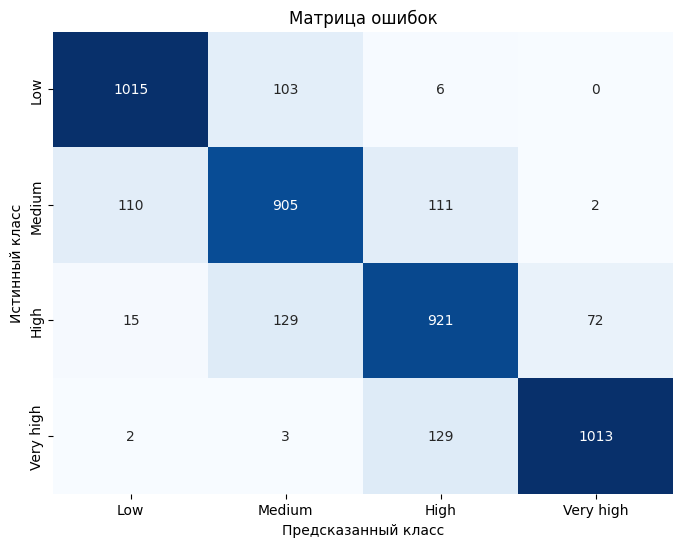

In [374]:
# Создание матрицы ошибок
plot_confusion_matrix(y_test_cls_optimized, y_test_pred_cls_base)

**f.	Сравнить результаты моделей с улучшенным бейзлайном в сравнении с результатами из пункта 2**

После улучшения бейзлайна на валидационной выборке модель стала работать примерно на 1% точнее, а на тренировочной примерно рзультат не поменялся. Причина, этому что датасет взят уже хорошо обработанный и сложно составить новые гипотезы

**g.	Сделать выводы**

Причина, этому что датасет взят уже хорошо обработанный и сложно составить новые гипотезы

### *Регрессия*

**d. Обучение модели с улучшенным бейзлайном на выбранном наборе данных**

In [375]:
df_beer_optimized = df_beer_temp

X_regression_optimized = df_beer_optimized.drop(['review_overall'], axis=1)
y_regression_optimized = df_beer_optimized['review_overall']
X_train_reg_optimized, X_test_reg_optimized, y_train_reg_optimized, y_test_reg_optimized = train_test_split(
    X_regression_optimized, y_regression_optimized, test_size=0.2, random_state=42
)


scaler = StandardScaler() 
X_train_reg_scaled_optimized = scaler.fit_transform(X_train_reg_optimized)
X_test_reg_scaled_optimized = scaler.transform(X_test_reg_optimized)

knn_regressor = KNeighborsRegressor(n_neighbors=3)
knn_regressor.fit(X_train_reg_scaled_optimized, y_train_reg_optimized)



KNeighborsRegressor(n_neighbors=3)

**e.	Оценка качества моделей с улучшенным бейзлайном по выбранным метрикам на выбранных наборах данных**

In [376]:
def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

def root_mean_squared_error(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

y_test_pred_reg_optimized = knn_regressor.predict(X_test_reg_scaled_optimized)
y_train_pred_reg_optimized = knn_regressor.predict(X_train_reg_scaled_optimized)

evaluate_regression(y_test_reg_optimized, y_test_pred_reg_optimized, 'Оценка на валидационной выборке:')

print()

evaluate_regression(y_train_reg_optimized, y_train_pred_reg_optimized, 'Оценка на тренировочной выборке:')

Оценка на валидационной выборке:
MAE = 0.2523
MAPE = 7.1350%
MSE = 0.1107
RMSE = 0.3327

Оценка на тренировочной выборке:
MAE = 0.1815
MAPE = 5.1339%
MSE = 0.0604
RMSE = 0.2458


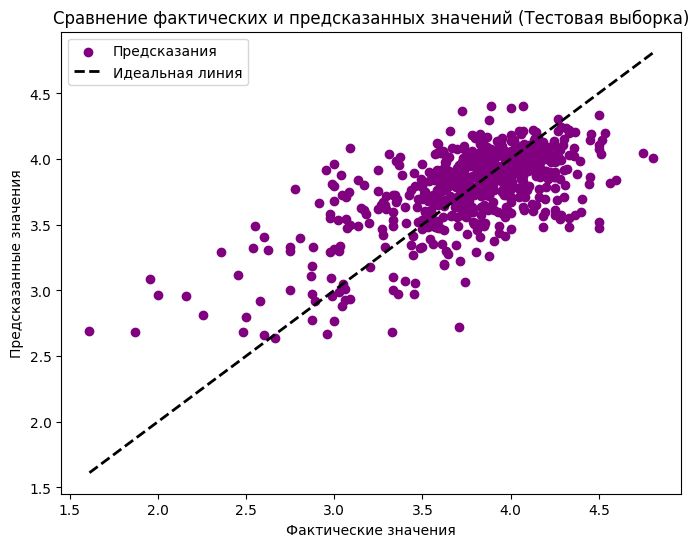

In [377]:
plot_scattering_diagram(y_test_reg_optimized, y_test_pred_reg_optimized)


**f.	Сравнить результаты моделей с улучшенным бейзлайном в сравнении с результатами из пункта 2**

На улучшенном бейзлайне модель показала следующие улучшения:

MAE (Средняя абсолютная ошибка) уменьшилась с 0.2709 до 0.25, что означает, что в среднем ошибки предсказания стали меньше.

MAPE (Средняя абсолютная процентная ошибка) снизилась с 7.58% до 7.13%, что говорит о том, что модель стала предсказывать значения с меньшей относительной ошибкой, хоть не существенной.

MSE (Среднеквадратичная ошибка) RMSE (Корень из MSE) почти не изминились

**g.	Сделать выводы**

Гипотезы немного улучшили результат, но особо ничего не поменялось

## **4.	Имплементация алгоритма машинного обучения**

**a. Самостоятельно имплементировать алгоритмы машинного обучения (для классификации и регрессии)**

In [378]:
def KNN(X_train, X_test, y_train, y_test=None, k=4, p=2, task='regression', batch_size=1000):
    X_train, y_train = map(np.array, (X_train, y_train))
    y_pred = []

    for i in range(0, len(X_test), batch_size):
        X_test_batch = X_test[i:i+batch_size]

        distances = np.linalg.norm(X_test_batch[:, np.newaxis] - X_train, axis=2, ord=p)

        nearest_neighbors_indices = np.argsort(distances, axis=1)[:, :k]
        nearest_neighbors_values = y_train[nearest_neighbors_indices]

        if task == 'classification':
            y_pred_batch = [
                Counter(neighbors).most_common(1)[0][0] for neighbors in nearest_neighbors_values
            ]
        elif task == 'regression':
            y_pred_batch = np.mean(nearest_neighbors_values, axis=1)
        else:
            raise ValueError("task должен быть 'classification' или 'regression'.")

        y_pred.extend(y_pred_batch)

    return np.array(y_pred)


#### *Классификация*

**b. Обучить имплементированную модель для выбранного набора данных**

In [379]:
y_pred_base = KNN(X_train_cls_scaled_base, X_test_cls_scaled_base,
             y_train_cls_base, y_test_cls_base, k=4, p=2, task='classification')

**c. Оценить качество имплементированной модели по выбранным метрикам на выбранном наборе данных**

In [380]:
evaluate_classification(y_test_cls_base, y_pred_base, 'Точность на валидационной выборке:')


Точность на валидационной выборке:
Accuracy = 0.8403880070546738
Balanced accuracy = 0.8404453520093573


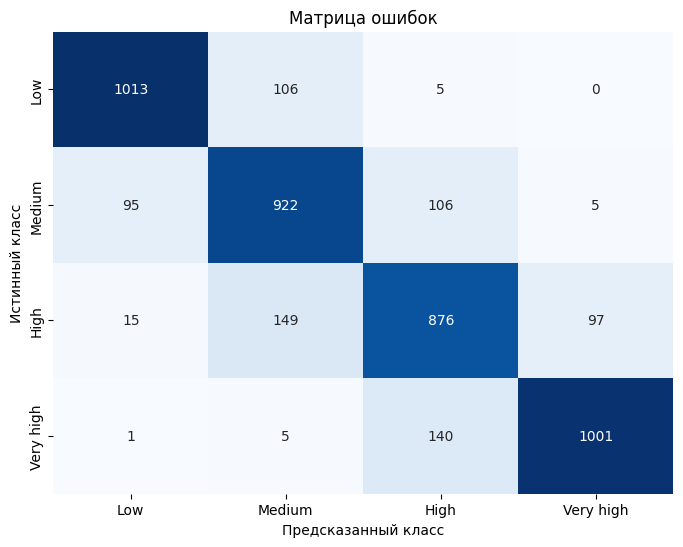

In [381]:
# Создание матрицы ошибок
plot_confusion_matrix(y_test_cls_base, y_pred_base)

**d. Сравнить результаты имплементированных моделей в сравнении с результатами из пункта 2**

Результат немного хуже < 1%, причина этому разный выбор классов

**e.	Сделать выводы**

+- Реализация показали одинаковый результат

**f.	Добавить техники из улучшенного бейзлайна (пункт 3с)**
Бейзлайн построен выше

**g.	Обучить модели для выбранного набора данных**

In [382]:
y_pred_optimized = KNN(X_train_cls_scaled_optimized, X_test_cls_scaled_optimized,
             y_train_cls_optimized, y_test_cls_optimized, k=11, p=2, task='classification')

**h.	Оценить качество модели по выбранным метрикам на выбранном наборе данных**

In [383]:
evaluate_classification(y_test_cls_optimized, y_pred_optimized, 'Точность на валидационной выборке:')

Точность на валидационной выборке:
Accuracy = 0.8381834215167548
Balanced accuracy = 0.8381995944703236


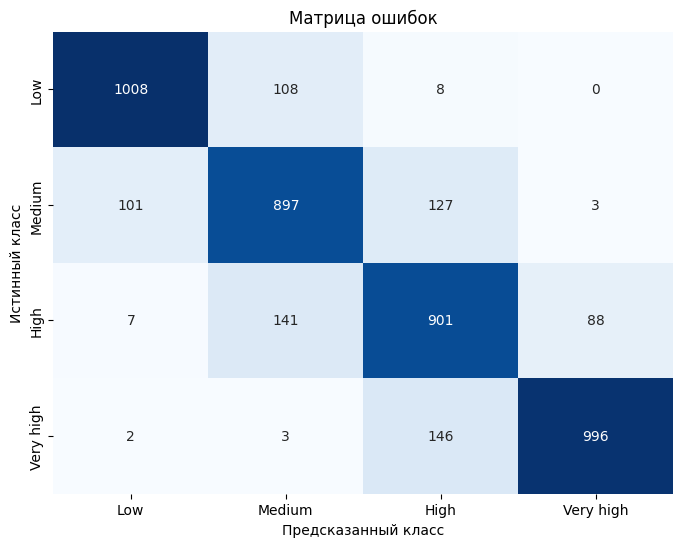

In [384]:
# Создание матрицы ошибок
plot_confusion_matrix(y_test_cls_optimized, y_pred_optimized)

**i.	Сравнить результаты модели в сравнении с результатами из пункта 3**

Увеличилась ошибка почти на 2%. Видно, что сильно просели High и Very High. Стали выбираться чаще рядом заданные классы, как пример для very high увеличился выбор High

**j.	Сделать выводы**

Своя реализация проигрывает. Есть вероятность, что значение были близки, и выбирался первый класс, менее подходящий (из-за порядка)

#### *Регрессия*

**b. Обучить имплементированную модель для выбранного набора данных**

In [385]:
y_pred_base = KNN(X_train_reg_scaled_base, X_test_reg_scaled_base,
             y_train_reg_base, y_test_reg_base, k=3, p=2, task='regression')

**c. Оценить качество имплементированной модели по выбранным метрикам на выбранном наборе данных**

In [386]:
evaluate_regression(y_test_reg_base, y_pred_base, 'Точность на валидационной выборке:')

Точность на валидационной выборке:
MAE = 0.2709
MAPE = 7.5804%
MSE = 0.1314
RMSE = 0.3625


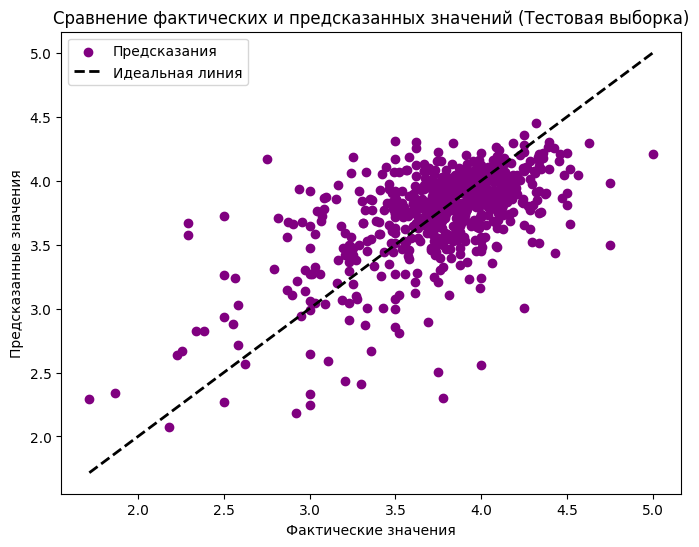

In [387]:
plot_scattering_diagram(y_test_reg_base, y_pred_base)

**d. Сравнить результаты имплементированных моделей в сравнении с результатами из пункта 2**

Ничего не поменялось, результаты теже, что и у sklearn

**e.	Сделать выводы**

Своя реализация выдала такой же резултат, как и реализация sklearn.

**f.	Добавить техники из улучшенного бейзлайна (пункт 3с)**

**g.	Обучить модели для выбранного набора данных**

In [388]:
y_pred_optimized = KNN(X_train_reg_scaled_optimized, X_test_reg_scaled_optimized,
             y_train_reg_optimized, y_test_reg_optimized, k=3, p=2, task='regression')

**h.	Оценить качество модели по выбранным метрикам на выбранном наборе данных**

In [389]:
evaluate_regression(y_test_reg_optimized, y_pred_optimized, 'Точность на валидационной выборке:')

Точность на валидационной выборке:
MAE = 0.2523
MAPE = 7.1350%
MSE = 0.1107
RMSE = 0.3327


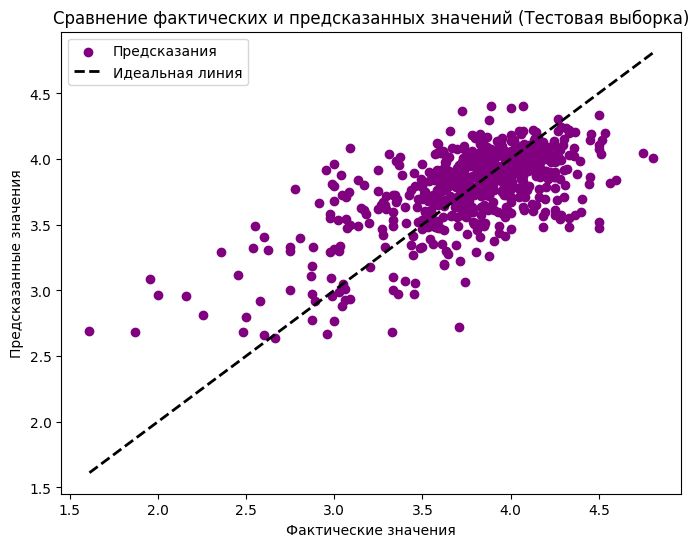

In [390]:
plot_scattering_diagram(y_test_reg_optimized, y_pred_optimized)

**i.	Сравнить результаты модели в сравнении с результатами из пункта 3**

Результаты как и в случае обычного бейзлайна индентичны

**j.	Сделать выводы**

Может сделать вывод, что своя реализация и реализация sklearn одинаковые

# **Лабораторная работа 2**

# **Проведение исследований с логистической и линейной регрессией**

## **2. Создание бейзлайна и оценка качества**

In [225]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, balanced_accuracy_score, mean_absolute_error, mean_squared_error
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.multiclass import OneVsRestClassifier

### Классификация

#### **a. Обучение модели из sklearn для выбранного набора данных**

In [226]:
X_classification_base = df_flats_base.drop(['Price', 'Price Category'], axis=1)
y_classification_base = df_flats_base['Price Category']
X_train_cls_base, X_test_cls_base, y_train_cls_base, y_test_cls_base = train_test_split(
    X_classification_base, y_classification_base, test_size=0.2, random_state=42
)


scaler = MinMaxScaler()
X_train_cls_scaled_base = scaler.fit_transform(X_train_cls_base)
X_test_cls_scaled_base = scaler.transform(X_test_cls_base)
logreg_classifier = LogisticRegression(max_iter=10000, solver='liblinear')
ovr_classifier = OneVsRestClassifier(logreg_classifier)
ovr_classifier.fit(X_train_cls_scaled_base, y_train_cls_base)

OneVsRestClassifier(estimator=LogisticRegression(max_iter=10000,
                                                 solver='liblinear'))

#### **b. Оценка качества модели по выбранным метрикам на выбранном наборе данных**

In [227]:
y_test_pred_cls_base = ovr_classifier.predict(X_test_cls_scaled_base)
y_train_pred_cls_base = ovr_classifier.predict(X_train_cls_scaled_base)

evaluate_classification(y_test_cls_base, y_test_pred_cls_base, 'Оценка на валидационной выборке:')

print()

evaluate_classification(y_train_cls_base, y_train_pred_cls_base, 'Оценка на тренировочной выборке:')

Оценка на валидационной выборке:
Accuracy = 0.7308201058201058
Balanced accuracy = 0.7305557010501533

Оценка на тренировочной выборке:
Accuracy = 0.7250275633958103
Balanced accuracy = 0.7251416865109069


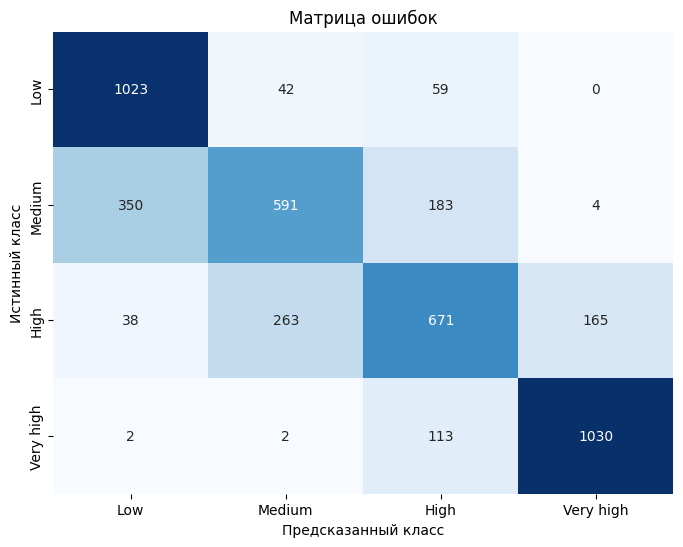

In [228]:
plot_confusion_matrix(y_test_cls_base, y_test_pred_cls_base)

In [229]:
null_accuracy_base = (y_test_cls_base.value_counts().max()/y_test_cls_base.value_counts().sum())
print('Null accuracy score: {0:0.4f}'. format(null_accuracy_base))

Null accuracy score: 0.2529


### *Регрессия*

#### **a. Обучение модели из sklearn для выбранного набора данных**

In [230]:
X_regression_base = df_beer_base.drop(['review_overall'], axis=1)
y_regression_base = df_beer_base["review_overall"]
X_train_reg_base, X_test_reg_base, y_train_reg_base, y_test_reg_base = train_test_split(
    X_regression_base, y_regression_base, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_reg_scaled_base = scaler.fit_transform(X_train_reg_base)
X_test_reg_scaled_base = scaler.transform(X_test_reg_base)

linear_regressor = LinearRegression()
linear_regressor.fit(X_train_reg_scaled_base, y_train_reg_base)

LinearRegression()

#### **b. Оценка качества модели по выбранным метрикам на выбранном наборе данных**

In [231]:
y_test_pred_reg_base = linear_regressor.predict(X_test_reg_scaled_base)
y_train_pred_reg_base = linear_regressor.predict(X_train_reg_scaled_base)

evaluate_regression(y_test_reg_base, y_test_pred_reg_base, 'Оценка на валидационной выборке:')

print()

evaluate_regression(y_train_reg_base, y_train_pred_reg_base, 'Оценка на тренировочной выборке:')

Оценка на валидационной выборке:
MAE = 0.2683
MAPE = 7.6147%
MSE = 0.1379
RMSE = 0.3714

Оценка на тренировочной выборке:
MAE = 0.2760
MAPE = 8.0763%
MSE = 0.1408
RMSE = 0.3753


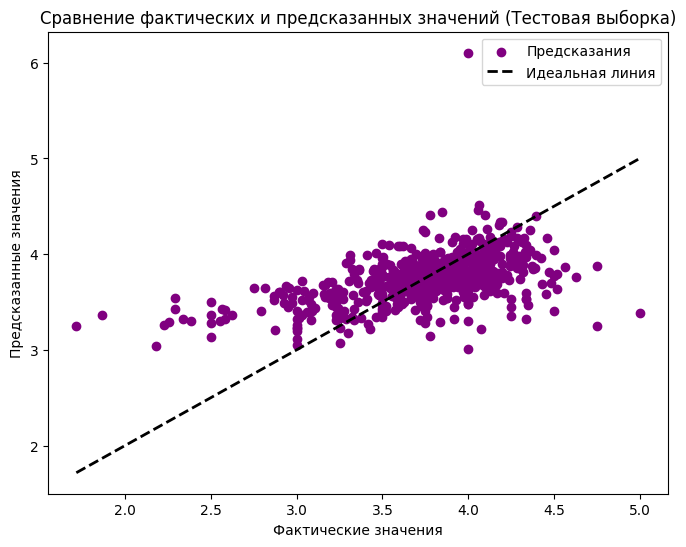

In [232]:
plot_scattering_diagram(y_test_reg_base, y_test_pred_reg_base)

## **3. Улучшение бейзлайна**

**a. b. c. Формирование гипотез и их проверка, а также формирование улучшенного бейзлайна по результатам проверки гипотез (препроцессинг данных, визуализация данных, формирование новых признаков, подбор гиперпараметров на кросс-валидации)**

### *Классификация*

**d. Обучение модели с улучшенным бейзлайном на выбранном наборе данных**

In [233]:
X_classification_optimized = df_flats_optimized.drop(columns=['Price', 'Price Category'], axis=1)
y_classification_optimized = df_flats_optimized['Price Category']

X_train_cls_optimized, X_test_cls_optimized, y_train_cls_optimized, y_test_cls_optimized = train_test_split(
    X_classification_optimized, y_classification_optimized, test_size=0.2, random_state=42
)


scaler = StandardScaler()
X_train_cls_scaled_optimized  = scaler.fit_transform(X_train_cls_optimized)
X_test_cls_scaled_optimized  = scaler.transform(X_test_cls_optimized)

logreg_classifier = LogisticRegression(max_iter=10000, solver='liblinear')
ovr_classifier = OneVsRestClassifier(logreg_classifier)
ovr_classifier.fit(X_train_cls_scaled_optimized, y_train_cls_optimized)

OneVsRestClassifier(estimator=LogisticRegression(max_iter=10000,
                                                 solver='liblinear'))

**e.	Оценка качества моделей с улучшенным бейзлайном по выбранным метрикам на выбранных наборах данных**

In [234]:
y_pred_train_cls_optimized = ovr_classifier.predict(X_train_cls_scaled_optimized)
y_pred_test_cls_optimized = ovr_classifier.predict(X_test_cls_scaled_optimized)

evaluate_classification(y_test_cls_optimized, y_pred_test_cls_optimized, 'Оценка на валидационной выборке:')

print()

evaluate_classification(y_train_cls_optimized, y_pred_train_cls_optimized, 'Оценка на тренировочной выборке:')

Оценка на валидационной выборке:
Accuracy = 0.7799823633156967
Balanced accuracy = 0.7798723031537133

Оценка на тренировочной выборке:
Accuracy = 0.7776185226019846
Balanced accuracy = 0.7776728296547601


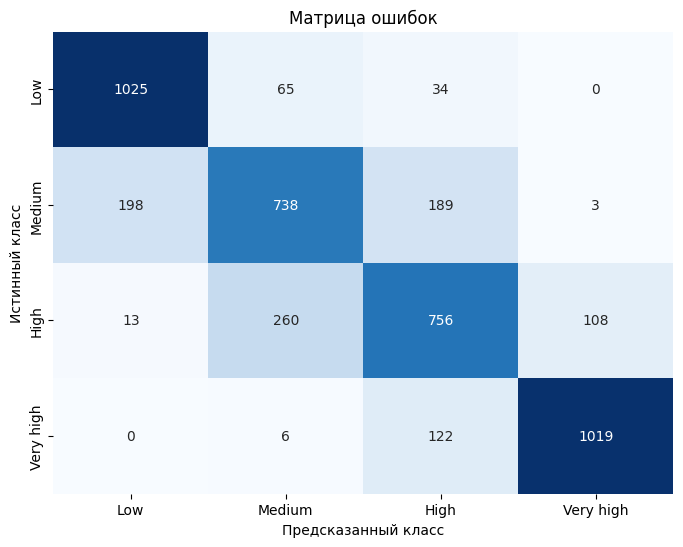

In [235]:
plot_confusion_matrix(y_test_cls_optimized, y_pred_test_cls_optimized)

**f.	Сравнить результаты моделей с улучшенным бейзлайном в сравнении с результатами из пункта 2**

Точность увеличилась на 4% на валидационной выборке и на тестовой на 5%.

**g.	Сделать выводы**

Результат на улучшенном бейзлайне превосходит на обычном бейзлайне. Но если сравнивать с KNN, то результат хуже. Скорее всего, это из-за чувствительности к выбросам

### *Регрессия*

**d. Обучение модели с улучшенным бейзлайном на выбранном наборе данных**

In [236]:
X_regression_optimized = df_beer_optimized.drop(['review_overall'], axis=1)
y_regression_optimized = df_beer_optimized["review_overall"]
X_train_reg_optimized, X_test_reg_optimized, y_train_reg_optimized, y_test_reg_optimized = train_test_split(
    X_regression_optimized, y_regression_optimized, test_size=0.2, random_state=42
)


scaler = StandardScaler()
X_train_reg_scaled_optimized = scaler.fit_transform(X_train_reg_optimized)
X_test_reg_scaled_optimized = scaler.transform(X_test_reg_optimized)

linear_regressor = LinearRegression()
linear_regressor.fit(X_train_reg_scaled_optimized, y_train_reg_optimized)

LinearRegression()

**e.	Оценка качества моделей с улучшенным бейзлайном по выбранным метрикам на выбранных наборах данных**

In [237]:
y_test_pred_reg_optimized = linear_regressor.predict(X_test_reg_scaled_optimized)
y_train_pred_reg_optimized = linear_regressor.predict(X_train_reg_scaled_optimized)

# Вывод результатов
evaluate_regression(y_test_reg_optimized, y_test_pred_reg_optimized, 'Оценка на валидационной выборке:')

print()

evaluate_regression(y_train_reg_optimized, y_train_pred_reg_optimized, 'Оценка на тренировочной выборке:')

Оценка на валидационной выборке:
MAE = 0.2748
MAPE = 7.9210%
MSE = 0.1369
RMSE = 0.3700

Оценка на тренировочной выборке:
MAE = 0.2664
MAPE = 7.7154%
MSE = 0.1329
RMSE = 0.3646


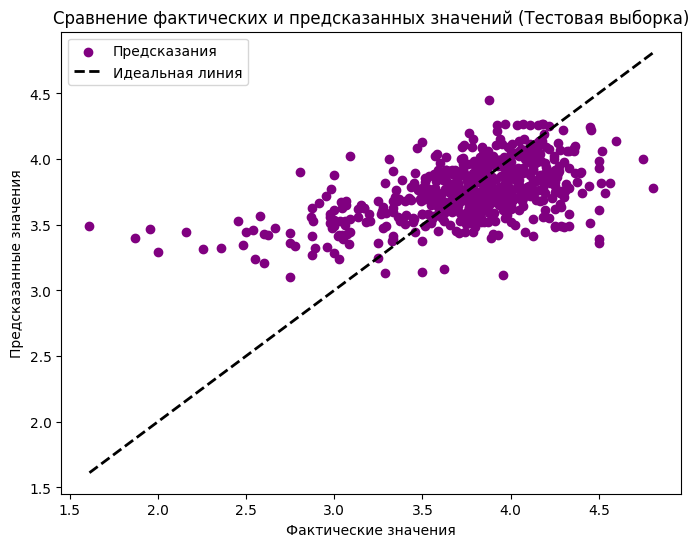

In [238]:
plot_scattering_diagram(y_test_reg_optimized, y_test_pred_reg_optimized)


**f.	Сравнить результаты моделей с улучшенным бейзлайном в сравнении с результатами из пункта 2**

MAE (Средняя абсолютная ошибка) увеличилась с 0.2683 до 0.2748, что показывается, что бейзлайн даже ухудшил результат

MAPE (Средняя абсолютная процентная ошибка) увеличилась с 7.61% до 7.92%, что говорит о том, что модель стала предсказывать значения с большей относительной ошибкой.

MSE (Среднеквадратичная ошибка) Несущественно увеличилось на 0.001

RMSE (Корень из MSE) Несущественно увеличилось на 0.001

В общем, модель на улучшенном бейзлайне показала более плохие результаты

**g.	Сделать выводы**

В данном случае модель на бейзлайне показала результат похуже. И если сравнивать с бейзлайном, то результат тоже хуже. Видимо зависимость целевой переменной от параметров - неленийная

## **4.	Имплементация алгоритма машинного обучения**

**a. Самостоятельно имплементировать алгоритмы машинного обучения (для классификации и регрессии)**

In [239]:
def custom_regression(X_train, y_train, X_test, task='classification', learning_rate=0.01, n_iterations=1000, tolerance=1e-6):
    if task == 'classification':
        return logistic_regression_multiclass(X_train, y_train, X_test, learning_rate, n_iterations, tolerance)
    elif task == 'regression':
        return linear_regression(X_train, y_train, X_test, learning_rate, n_iterations, tolerance)
    else:
        raise ValueError("Task must be 'classification' or 'regression'")

def logistic_regression_multiclass(X_train, y_train, X_test, learning_rate=0.01, n_iterations=1000, tolerance=1e-6):
    n_samples, n_features = X_train.shape
    n_classes = len(np.unique(y_train))

    class_map = {label: idx for idx, label in enumerate(np.unique(y_train))}
    y_train_num = np.array([class_map[label] for label in y_train])

    weights = np.zeros((n_features, n_classes))
    bias = np.zeros(n_classes)

    for _ in range(n_iterations):
        model = np.dot(X_train, weights) + bias
        predictions = softmax(model)

        dw = (1 / n_samples) * np.dot(X_train.T, (predictions - one_hot_encode(y_train_num, n_classes)))
        db = (1 / n_samples) * np.sum(predictions - one_hot_encode(y_train_num, n_classes), axis=0)

        weights -= learning_rate * dw
        bias -= learning_rate * db

        if np.linalg.norm(dw) < tolerance and np.max(np.abs(db)) < tolerance:
            break

    model_test = np.dot(X_test, weights) + bias
    y_pred_prob = softmax(model_test)
    y_pred_classes = np.argmax(y_pred_prob, axis=1)

    reverse_class_map = {v: k for k, v in class_map.items()}
    y_pred_labels = [reverse_class_map[label] for label in y_pred_classes]

    return np.array(y_pred_labels)

def softmax(x):
    exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)

def one_hot_encode(y, n_classes):
    return np.eye(n_classes)[y]

def linear_regression(X_train, y_train, X_test, learning_rate=0.01, n_iterations=1000, tolerance=1e-6):
    n_samples, n_features = X_train.shape
    weights = np.zeros(n_features)
    bias = 0

    for _ in range(n_iterations):
        model = np.dot(X_train, weights) + bias
        predictions = model

        dw = (2 / n_samples) * np.dot(X_train.T, (predictions - y_train))
        db = (2 / n_samples) * np.sum(predictions - y_train)

        weights -= learning_rate * dw
        bias -= learning_rate * db

        if np.linalg.norm(dw) < tolerance and np.abs(db) < tolerance:
            break

    model_test = np.dot(X_test, weights) + bias
    return model_test


#### *Классификация*

**b. Обучить имплементированную модель для выбранного набора данных**

In [240]:
y_pred_base = custom_regression(X_train_cls_scaled_base, y_train_cls_base, X_test_cls_scaled_base, task='classification', learning_rate=0.15, n_iterations=10000)

**c. Оценить качество имплементированной модели по выбранным метрикам на выбранном наборе данных**

In [241]:
evaluate_classification(y_test_cls_base, y_pred_base, 'Точность на валидационной выборке:')

Точность на валидационной выборке:
Accuracy = 0.7367724867724867
Balanced accuracy = 0.736494515879877


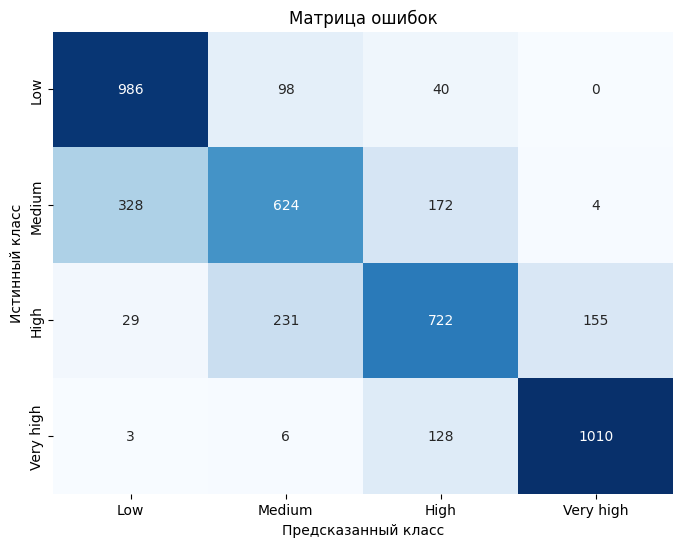

In [242]:
plot_confusion_matrix(y_test_cls_base, y_pred_base)

**d. Сравнить результаты имплементированных моделей в сравнении с результатами из пункта 2**

Точность своей реализации немного больше, а именно на 0.006

**e.	Сделать выводы**

Реализации +- одинаковые по точности

**f.	Добавить техники из улучшенного бейзлайна (пункт 3с)**
P.S. улучшение в начале ЛР

**g.	Обучить модели для выбранного набора данных**

In [243]:
y_pred_optimized = custom_regression(X_train_cls_scaled_optimized, y_train_cls_optimized, X_test_cls_scaled_optimized, task='classification', learning_rate=0.01, n_iterations=10000)

**h.	Оценить качество модели по выбранным метрикам на выбранном наборе данных**

In [244]:
evaluate_classification(y_test_cls_optimized, y_pred_optimized, 'Точность на валидационной выборке:')

Точность на валидационной выборке:
Accuracy = 0.8077601410934744
Balanced accuracy = 0.8076917213498467


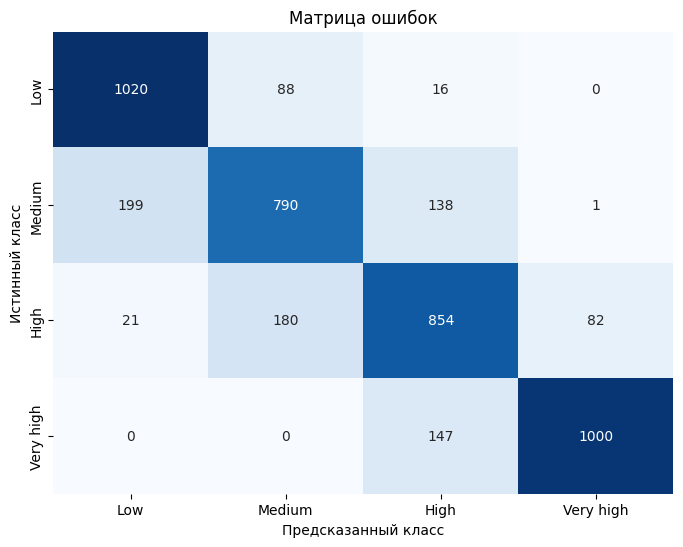

In [245]:
# Создание матрицы ошибок
plot_confusion_matrix(y_test_cls_optimized, y_pred_optimized)

**i.	Сравнить результаты модели в сравнении с результатами из пункта 3**

Точность своей реализации лучше на 3%, что говорит о хорошем результате

**j.	Сделать выводы**

Моя имплементацияя логистической регрессии работает с лучшей точностью, чем реализация sklearn на улучшенном бейзлайне

#### *Регрессия*

**b. Обучить имплементированную модель для выбранного набора данных**

In [246]:
y_pred_base = custom_regression(X_train_reg_scaled_base, y_train_reg_base, X_test_reg_scaled_base, task='regression', learning_rate=0.01, n_iterations=1000)

**c. Оценить качество имплементированной модели по выбранным метрикам на выбранном наборе данных**

In [247]:
evaluate_regression(y_test_reg_base, y_pred_base, 'Точность на валидационной выборке:')

Точность на валидационной выборке:
MAE = 0.2683
MAPE = 7.6174%
MSE = 0.1375
RMSE = 0.3708


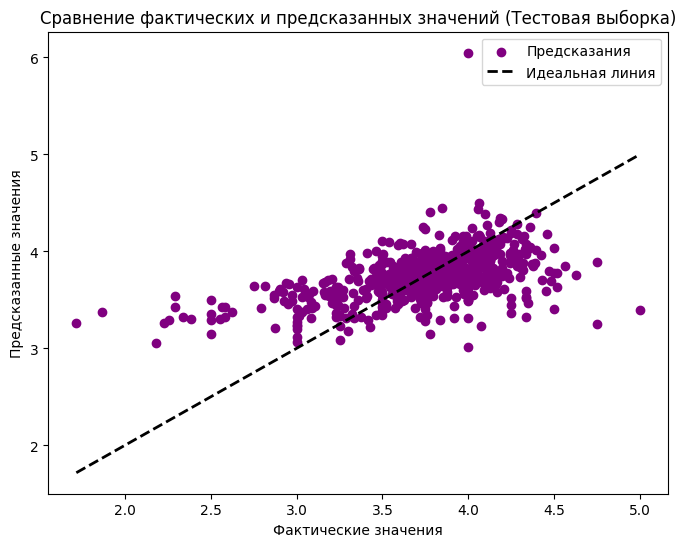

In [248]:
plot_scattering_diagram(y_test_reg_base, y_pred_base)

**d. Сравнить результаты имплементированных моделей в сравнении с результатами из пункта 2**

MAE (Средняя абсолютная ошибка) одинаковая
MAPE (Средняя абсолютная процентная ошибка) увеличилась на 0.0027
MSE (Среднеквадратичная ошибка)  уменьшилось на 0.004
RMSE (Корень из MSE) уменьшилось на 0.006

**e.	Сделать выводы**

Собственная реализация работает сравнима с sklearn, разници нет

**f.	Добавить техники из улучшенного бейзлайна (пункт 3с)**

**g.	Обучить модели для выбранного набора данных**

In [249]:
y_pred_optimized = custom_regression(X_train_reg_scaled_optimized, y_train_reg_optimized, X_test_reg_scaled_optimized, task='regression', learning_rate=0.01, n_iterations=1000)

**h.	Оценить качество модели по выбранным метрикам на выбранном наборе данных**

In [250]:
evaluate_regression(y_test_reg_optimized, y_pred_optimized, 'Точность на валидационной выборке:')

Точность на валидационной выборке:
MAE = 0.2751
MAPE = 7.9309%
MSE = 0.1371
RMSE = 0.3703


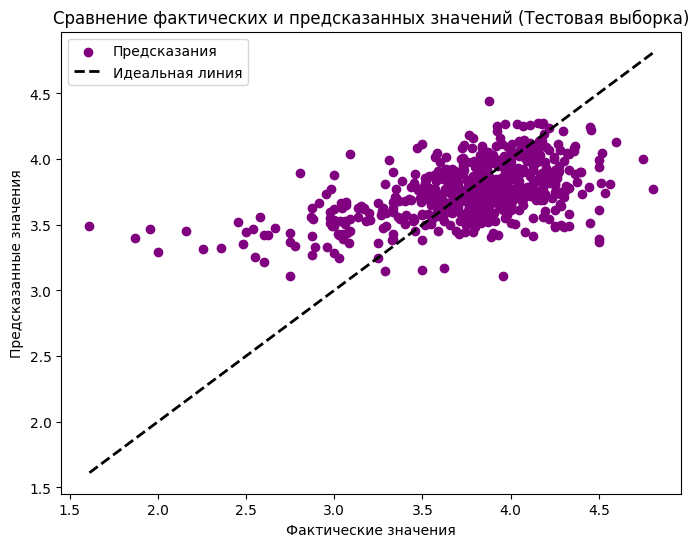

In [251]:
plot_scattering_diagram(y_test_reg_optimized, y_pred_optimized)

**i.	Сравнить результаты модели в сравнении с результатами из пункта 3**

MAE (Средняя абсолютная ошибка) увеличилось на 0.0004
MAPE (Средняя абсолютная процентная ошибка) увеличилась на 0.029
MSE (Среднеквадратичная ошибка)  увеличилось на 0.0002
RMSE (Корень из MSE) уменьшилось на 0.0003

**j.	Сделать выводы**

Собственная реализация работает сравнима с sklearn, разници нет

# **Лабораторная работа 3**

# **Проведение исследований с решающим деревом**

## **2. Создание бейзлайна и оценка качества**

In [252]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor

### Классификация

#### **a. Обучение модели из sklearn для выбранного набора данных**

In [253]:
X_classification_base = df_flats_base.drop(["Price", "Price Category"], axis=1)
y_classification_base = df_flats_base["Price Category"]
X_train_cls_base, X_test_cls_base, y_train_cls_base, y_test_cls_base = train_test_split(
    X_classification_base, y_classification_base, test_size=0.2, random_state=42
)


scaler = StandardScaler()
X_train_cls_scaled_base = scaler.fit_transform(X_train_cls_base)
X_test_cls_scaled_base = scaler.transform(X_test_cls_base)

dt_classifier = DecisionTreeClassifier(random_state=42)
dt_classifier.fit(X_train_cls_scaled_base, y_train_cls_base)

DecisionTreeClassifier(random_state=42)

#### **b. Оценка качества модели по выбранным метрикам на выбранном наборе данных**

In [254]:
y_test_pred_cls_base = dt_classifier.predict(X_test_cls_scaled_base)
y_train_pred_cls_base = dt_classifier.predict(X_train_cls_scaled_base)

evaluate_classification(y_test_cls_base, y_test_pred_cls_base, 'Оценка на валидационной выборке:')

print()

evaluate_classification(y_train_cls_base, y_train_pred_cls_base, 'Оценка на тренировочной выборке:')

Оценка на валидационной выборке:
Accuracy = 0.8564814814814815
Balanced accuracy = 0.8565266054265369

Оценка на тренировочной выборке:
Accuracy = 0.9942668136714443
Balanced accuracy = 0.9942811868433674


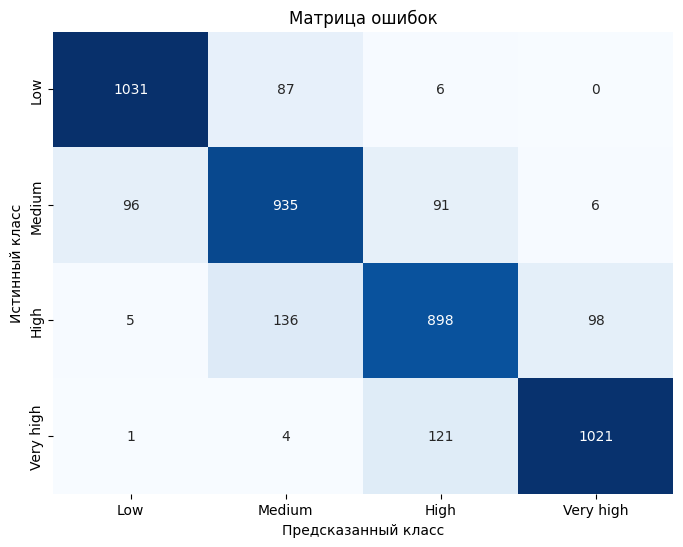

In [255]:
plot_confusion_matrix(y_test_cls_base, y_test_pred_cls_base)

**Точность модели (Accuracy)** на валидационной выборке составляет 70.05%, что является не является выдающимся результатом, но и не ужасным при предсказании одного из 4 классов.

In [256]:
null_accuracy_base = (y_test_cls_base.value_counts().max()/y_test_cls_base.value_counts().sum())
print('Null accuracy score: {0:0.4f}'. format(null_accuracy_base))

Null accuracy score: 0.2529


Мы видим, что показатель точности нашей модели равен 0,7005, а нулевой показатель точности равен 0,2747. Таким образом, мы можем заключить, что наша модель решающего дерева хорошо справляется с предсказанием меток ценовых классов.

### *Регрессия*

#### **a. Обучение модели из sklearn для выбранного набора данных**

In [257]:
X_regression_base = df_beer_base.drop(['review_overall'], axis=1)
y_regression_base = df_beer_base['review_overall']
X_train_reg_base, X_test_reg_base, y_train_reg_base, y_test_reg_base = train_test_split(
    X_regression_base, y_regression_base, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_reg_scaled_base = scaler.fit_transform(X_train_reg_base)
X_test_reg_scaled_base = scaler.transform(X_test_reg_base)

dt_regressor = DecisionTreeRegressor(random_state=42)
dt_regressor .fit(X_train_reg_scaled_base, y_train_reg_base)

DecisionTreeRegressor(random_state=42)

#### **b. Оценка качества модели по выбранным метрикам на выбранном наборе данных**

In [258]:
y_test_pred_reg_base = dt_regressor.predict(X_test_reg_scaled_base)
y_train_pred_reg_base = dt_regressor.predict(X_train_reg_scaled_base)

evaluate_regression(y_test_reg_base, y_test_pred_reg_base, 'Оценка на валидационной выборке:')

print()

evaluate_regression(y_train_reg_base, y_train_pred_reg_base, 'Оценка на тренировочной выборке:')

Оценка на валидационной выборке:
MAE = 0.3167
MAPE = 8.8683%
MSE = 0.1879
RMSE = 0.4335

Оценка на тренировочной выборке:
MAE = 0.0000
MAPE = 0.0000%
MSE = 0.0000
RMSE = 0.0000


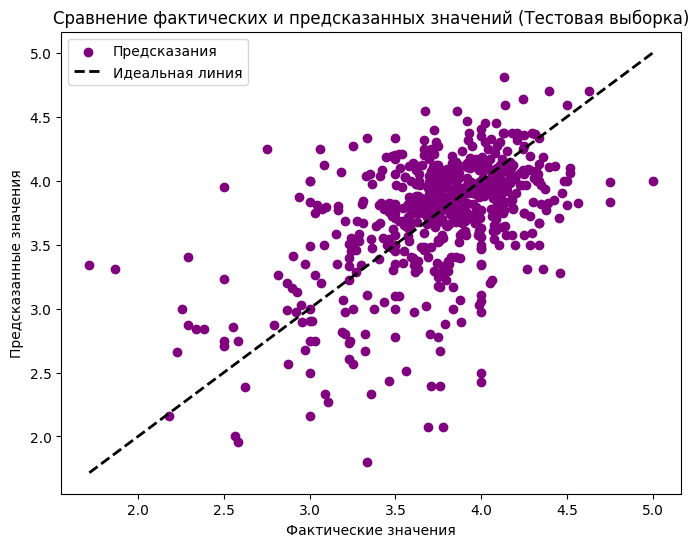

In [259]:
plot_scattering_diagram(y_test_reg_base, y_test_pred_reg_base)

## **3. Улучшение бейзлайна**

**a. b. c. Формирование гипотез и их проверка, а также формирование улучшенного бейзлайна по результатам проверки гипотез (препроцессинг данных, визуализация данных, формирование новых признаков, подбор гиперпараметров на кросс-валидации)**

### *Классификация*

**d. Обучение модели с улучшенным бейзлайном на выбранном наборе данных**

In [260]:
X_classification_optimized = df_flats_optimized.drop(columns=["Price", "Price Category"], axis=1)
y_classification_optimized = df_flats_optimized["Price Category"]

X_train_cls_optimized, X_test_cls_optimized, y_train_cls_optimized, y_test_cls_optimized = train_test_split(
    X_classification_optimized, y_classification_optimized, test_size=0.2, random_state=42
)


scaler = StandardScaler()
X_train_cls_scaled_optimized  = scaler.fit_transform(X_train_cls_optimized)
X_test_cls_scaled_optimized  = scaler.transform(X_test_cls_optimized)

dt_classifier = DecisionTreeClassifier(random_state=42) 
dt_classifier.fit(X_train_cls_scaled_optimized, y_train_cls_optimized)

DecisionTreeClassifier(random_state=42)

**e.	Оценка качества моделей с улучшенным бейзлайном по выбранным метрикам на выбранных наборах данных**

In [261]:
y_pred_train_cls_optimized = dt_classifier.predict(X_train_cls_scaled_optimized)
y_pred_test_cls_optimized = dt_classifier.predict(X_test_cls_scaled_optimized)

evaluate_classification(y_test_cls_optimized, y_pred_test_cls_optimized, 'Оценка на валидационной выборке:')

print()

evaluate_classification(y_train_cls_optimized, y_pred_train_cls_optimized, 'Оценка на тренировочной выборке:')

Оценка на валидационной выборке:
Accuracy = 0.8443562610229277
Balanced accuracy = 0.8444105957178527

Оценка на тренировочной выборке:
Accuracy = 0.9942668136714443
Balanced accuracy = 0.9942811868433674


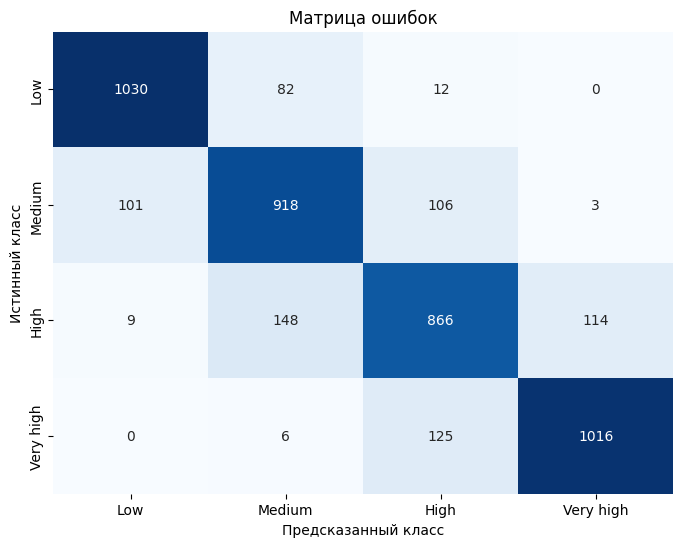

In [262]:
plot_confusion_matrix(y_test_cls_optimized, y_pred_test_cls_optimized)

**f.	Сравнить результаты моделей с улучшенным бейзлайном в сравнении с результатами из пункта 2**

После улучшения бейзлайна на валидационной выборке модель стала работать на 1% процент хуже

**g.	Сделать выводы**

Улучшений бейзлайн никак в данном кейсе не улучшил модель

### *Регрессия*

**d. Обучение модели с улучшенным бейзлайном на выбранном наборе данных**

In [263]:
X_regression_optimized = df_beer_optimized.drop(['review_overall'], axis=1)
y_regression_optimized = df_beer_optimized["review_overall"]
X_train_reg_optimized, X_test_reg_optimized, y_train_reg_optimized, y_test_reg_optimized = train_test_split(
    X_regression_optimized, y_regression_optimized, test_size=0.2, random_state=42
)


scaler = StandardScaler()
X_train_reg_scaled_optimized = scaler.fit_transform(X_train_reg_optimized)
X_test_reg_scaled_optimized = scaler.transform(X_test_reg_optimized)

# Обучение модели регрессии
dt_regressor = DecisionTreeRegressor(random_state=42) 
dt_regressor.fit(X_train_reg_scaled_optimized, y_train_reg_optimized)

DecisionTreeRegressor(random_state=42)

**e.	Оценка качества моделей с улучшенным бейзлайном по выбранным метрикам на выбранных наборах данных**

In [264]:
y_test_pred_reg_optimized = dt_regressor.predict(X_test_reg_scaled_optimized)
y_train_pred_reg_optimized = dt_regressor.predict(X_train_reg_scaled_optimized)

evaluate_regression(y_test_reg_optimized, y_test_pred_reg_optimized, 'Оценка на валидационной выборке:')

print()

evaluate_regression(y_train_reg_optimized, y_train_pred_reg_optimized, 'Оценка на тренировочной выборке:')

Оценка на валидационной выборке:
MAE = 0.3209
MAPE = 9.0588%
MSE = 0.1894
RMSE = 0.4352

Оценка на тренировочной выборке:
MAE = 0.0000
MAPE = 0.0000%
MSE = 0.0000
RMSE = 0.0000


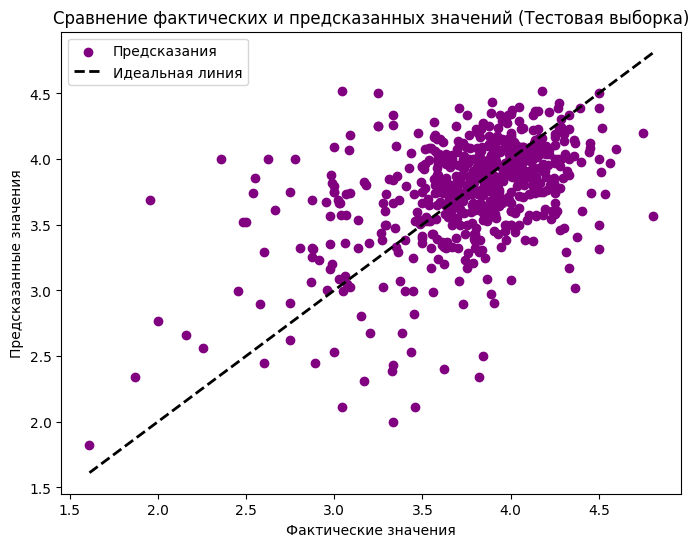

In [265]:
plot_scattering_diagram(y_test_reg_optimized, y_test_pred_reg_optimized)


**f.	Сравнить результаты моделей с улучшенным бейзлайном в сравнении с результатами из пункта 2**

MAE (Средняя абсолютная ошибка) увеличилось на 0.0032
MAPE (Средняя абсолютная процентная ошибка) увеличилась на 0.048
MSE (Среднеквадратичная ошибка)  увеличилось на 0.0015
RMSE (Корень из MSE) уменьшилось на 0.0017

**g.	Сделать выводы**

Результат примерно одинаков с обычном бейзлайном

## **4.	Имплементация алгоритма машинного обучения**

**a. Самостоятельно имплементировать алгоритмы машинного обучения (для классификации и регрессии)**

In [266]:
def entropy(y):
    class_counts = Counter(y)
    probabilities = np.array(list(class_counts.values())) / len(y)
    return -np.sum(probabilities * np.log2(probabilities))

def gini_impurity(y):
    class_counts = Counter(y)
    probabilities = np.array(list(class_counts.values())) / len(y)
    return 1 - np.sum(probabilities ** 2)

def mean_squared_error(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

def best_split(X, y, criterion='gini'):
    best_impurity = float('inf')
    best_split_info = None
    n_samples, n_features = X.shape

    for feature_idx in range(n_features):
        possible_splits = np.unique(X[:, feature_idx])

        for threshold in possible_splits:
            left_mask = X[:, feature_idx] <= threshold
            right_mask = ~left_mask
            y_left, y_right = y[left_mask], y[right_mask]

            if len(y_left) == 0 or len(y_right) == 0:
                continue

            if criterion == 'gini':
                impurity = gini_impurity(y_left) * len(y_left) / n_samples + gini_impurity(y_right) * len(y_right) / n_samples
            elif criterion == 'entropy':
                impurity = entropy(y_left) * len(y_left) / n_samples + entropy(y_right) * len(y_right) / n_samples
            elif criterion == 'mse':
                left_pred = np.mean(y_left)
                right_pred = np.mean(y_right)
                impurity = (np.mean((y_left - left_pred) ** 2) * len(y_left) + np.mean((y_right - right_pred) ** 2) * len(y_right)) / n_samples
            else:
                raise ValueError("Criterion must be 'gini', 'entropy' or 'mse'")

            if impurity < best_impurity:
                best_impurity = impurity
                best_split_info = (feature_idx, threshold)

    return best_split_info

def build_tree(X, y, task='classification', max_depth=None, min_samples_split=2, depth=0, criterion='gini'):
    n_samples, n_features = X.shape
    unique_classes = np.unique(y)

    if len(unique_classes) == 1 or (max_depth and depth == max_depth) or n_samples < min_samples_split:
        if task == 'classification':
            return Counter(y).most_common(1)[0][0]  
        elif task == 'regression':
            return np.mean(y)  

    best_split_info = best_split(X, y, criterion)
    if not best_split_info:
        return np.mean(y) if task == 'regression' else Counter(y).most_common(1)[0][0]

    feature_idx, threshold = best_split_info
    left_mask = X[:, feature_idx] <= threshold
    right_mask = ~left_mask
    X_left, y_left = X[left_mask], y[left_mask]
    X_right, y_right = X[right_mask], y[right_mask]

    left_node = build_tree(X_left, y_left, task, max_depth, min_samples_split, depth+1, criterion)
    right_node = build_tree(X_right, y_right, task, max_depth, min_samples_split, depth+1, criterion)

    return (feature_idx, threshold, left_node, right_node)

def predict_tree(tree, X):
    if isinstance(tree, tuple):
        feature_idx, threshold, left_node, right_node = tree
        if X[feature_idx] <= threshold:
            return predict_tree(left_node, X)
        else:
            return predict_tree(right_node, X)
    else:
        return tree 
    
def decision_tree(X_train, y_train, X_test, task='classification', max_depth=None, min_samples_split=2, criterion='gini'):
    tree = build_tree(X_train, y_train, task, max_depth, min_samples_split, criterion=criterion)
    y_pred = np.array([predict_tree(tree, x) for x in X_test])
    return y_pred

#### *Классификация*

**b. Обучить имплементированную модель для выбранного набора данных**

In [267]:
y_pred_base = decision_tree(X_train_cls_scaled_base, y_train_cls_base, X_test_cls_scaled_base, task='classification', criterion='gini')

**c. Оценить качество имплементированной модели по выбранным метрикам на выбранном наборе данных**

In [268]:
evaluate_classification(y_test_cls_base, y_pred_base, 'Точность на валидационной выборке:')

Точность на валидационной выборке:
Accuracy = 0.857363315696649
Balanced accuracy = 0.8574046593782206


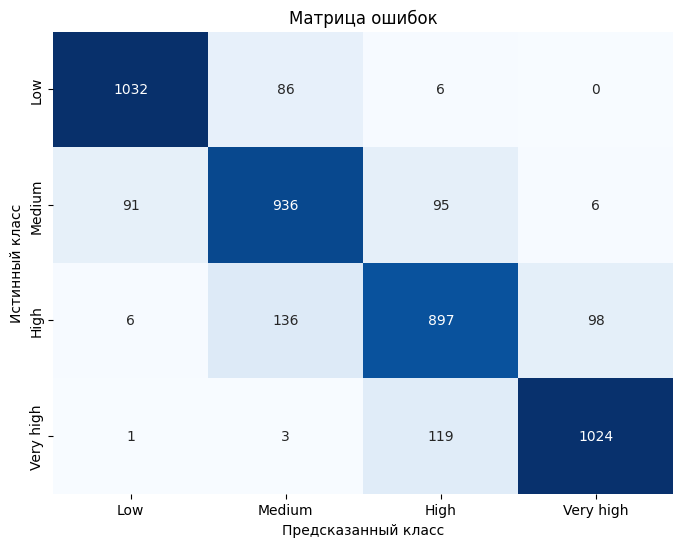

In [269]:
plot_confusion_matrix(y_test_cls_base, y_pred_base)

**d. Сравнить результаты имплементированных моделей в сравнении с результатами из пункта 2**

Разница в тысячных долях. Можно считать результат индентичным

**e.	Сделать выводы**

Собственная реализация совпдает по точности с sklearn моделью

**f.	Добавить техники из улучшенного бейзлайна (пункт 3с)**

**g.	Обучить модели для выбранного набора данных**

In [270]:
y_pred_optimized = decision_tree(X_train_cls_scaled_optimized, y_train_cls_optimized, X_test_cls_scaled_optimized, task='classification', criterion='gini')

**h.	Оценить качество модели по выбранным метрикам на выбранном наборе данных**

In [271]:
evaluate_classification(y_test_cls_optimized, y_pred_optimized, 'Точность на валидационной выборке:')

Точность на валидационной выборке:
Accuracy = 0.8487654320987654
Balanced accuracy = 0.8488382433801944


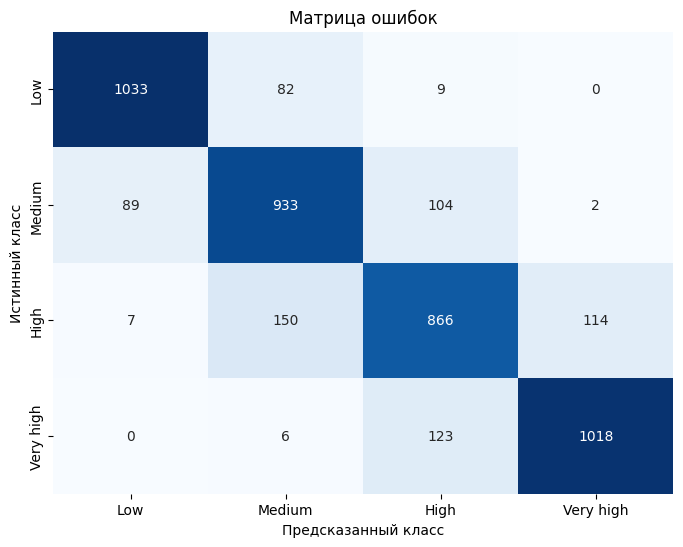

In [272]:
plot_confusion_matrix(y_test_cls_optimized, y_pred_optimized)

**i.	Сравнить результаты модели в сравнении с результатами из пункта 3**

Резулаты по сравнение с sklearn, можно считать, что точность одинаковая

**j.	Сделать выводы**

Точность хуже чем у базового бейзлайна, но это проблема и sklearn модели. В целом, кажется реалзция одинаковые

#### *Регрессия*

**b. Обучить имплементированную модель для выбранного набора данных**

In [273]:
y_pred_base = decision_tree(X_train_reg_scaled_base, y_train_reg_base, X_test_reg_scaled_base, task='regression', criterion='mse')

**c. Оценить качество имплементированной модели по выбранным метрикам на выбранном наборе данных**

In [274]:
evaluate_regression(y_test_reg_base, y_pred_base, 'Точность на валидационной выборке:')

Точность на валидационной выборке:
MAE = 0.3084
MAPE = 8.5842%
MSE = 0.1713
RMSE = 0.4138


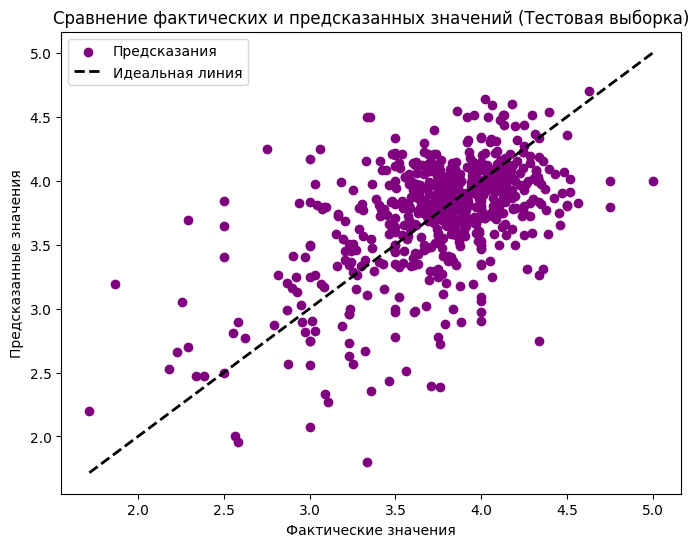

In [275]:
# Диаграмма рассеивания на тестовой выборке
plot_scattering_diagram(y_test_reg_base, y_pred_base)

**d. Сравнить результаты имплементированных моделей в сравнении с результатами из пункта 2**

MAE (Средняя абсолютная ошибка) уменьшилась на 0.1
MAPE (Средняя абсолютная процентная ошибка) уменьшилась 0.1
MSE (Среднеквадратичная ошибка)  уменьшилось 0.1
RMSE (Корень из MSE) уменьшилось 0.1

**e.	Сделать выводы**

Моя модель чуть лучше чем в sklearn

**f.	Добавить техники из улучшенного бейзлайна (пункт 3с)**

**g.	Обучить модели для выбранного набора данных**

In [276]:
y_pred_optimized = decision_tree(X_train_reg_scaled_optimized, y_train_reg_optimized, X_test_reg_scaled_optimized, task='regression', criterion='mse')

**h.	Оценить качество модели по выбранным метрикам на выбранном наборе данных**

In [277]:
evaluate_regression(y_test_reg_optimized, y_pred_optimized, 'Точность на валидационной выборке:')

Точность на валидационной выборке:
MAE = 0.3158
MAPE = 8.8180%
MSE = 0.1850
RMSE = 0.4301


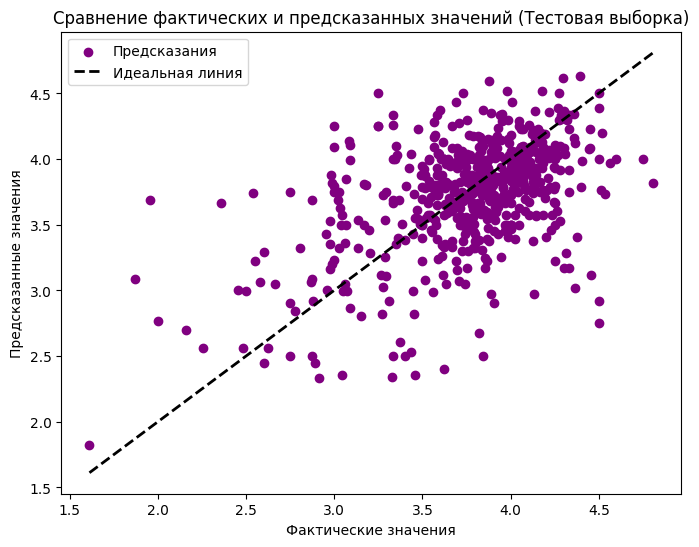

In [278]:
plot_scattering_diagram(y_test_reg_optimized, y_pred_optimized)

**i.	Сравнить результаты модели в сравнении с результатами из пункта 3**

MAE (Средняя абсолютная ошибка) уменьшилась на 0.05
MAPE (Средняя абсолютная процентная ошибка) уменьшилась 0.09
MSE (Среднеквадратичная ошибка)  уменьшилось 0.04
RMSE (Корень из MSE) уменьшилось 0.004

**j.	Сделать выводы**

Моя модель чуть лучше, можно сказать почти одинаковая с sklearn моделью

# **Лабораторная работа 4**

# **Проведение исследований со случайным лесом**

## **2. Создание бейзлайна и оценка качества**

In [279]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

### Классификация

#### **a. Обучение модели из sklearn для выбранного набора данных**

In [280]:
X_classification_base = df_flats_base.drop(["Price", "Price Category"], axis=1)
y_classification_base = df_flats_base["Price Category"]
X_train_cls_base, X_test_cls_base, y_train_cls_base, y_test_cls_base = train_test_split(
    X_classification_base, y_classification_base, test_size=0.2, random_state=42
)


scaler = StandardScaler()
X_train_cls_scaled_base = scaler.fit_transform(X_train_cls_base)
X_test_cls_scaled_base = scaler.transform(X_test_cls_base)

rf_classifier = RandomForestClassifier(random_state=42)
rf_classifier.fit(X_train_cls_scaled_base, y_train_cls_base)

RandomForestClassifier(random_state=42)

#### **b. Оценка качества модели по выбранным метрикам на выбранном наборе данных**

In [281]:
y_test_pred_cls_base = rf_classifier.predict(X_test_cls_scaled_base)
y_train_pred_cls_base = rf_classifier.predict(X_train_cls_scaled_base)

evaluate_classification(y_test_cls_base, y_test_pred_cls_base, 'Оценка на валидационной выборке:')

print()

evaluate_classification(y_train_cls_base, y_train_pred_cls_base, 'Оценка на тренировочной выборке:')

Оценка на валидационной выборке:
Accuracy = 0.8913139329805997
Balanced accuracy = 0.8912910727119852

Оценка на тренировочной выборке:
Accuracy = 0.9942668136714443
Balanced accuracy = 0.9942787600893065


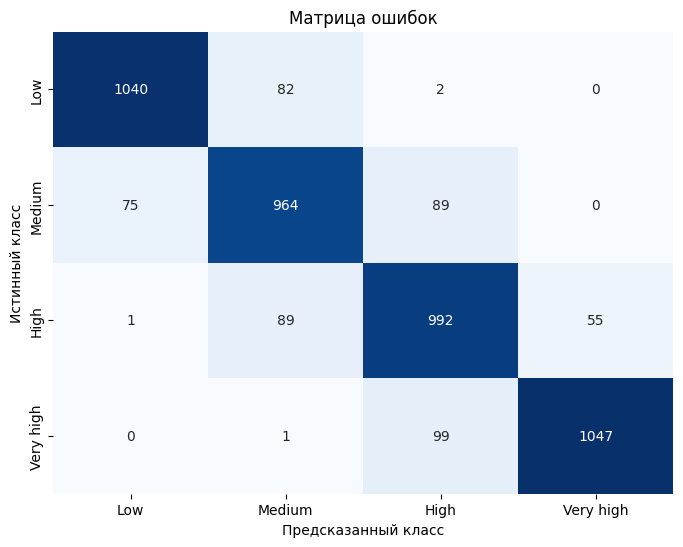

In [282]:
plot_confusion_matrix(y_test_cls_base, y_test_pred_cls_base)

**Точность модели (Accuracy)** на валидационной выборке составляет 70.60%, что является хорошим результатом при предсказании одного из 4 классов.

In [283]:
null_accuracy_base = (y_test_cls_base.value_counts().max()/y_test_cls_base.value_counts().sum())
print('Null accuracy score: {0:0.4f}'. format(null_accuracy_base))

Null accuracy score: 0.2529


Мы видим, что показатель точности нашей модели равен 0,7060, а нулевой показатель точности равен 0,2747. Таким образом, мы можем заключить, что наша модель логистической регрессии хорошо справляется с предсказанием меток ценовых классов.

### *Регрессия*

#### **a. Обучение модели из sklearn для выбранного набора данных**

In [284]:
X_regression_base = df_beer_base.drop(['review_overall'], axis=1)
y_regression_base = df_beer_base["review_overall"]
X_train_reg_base, X_test_reg_base, y_train_reg_base, y_test_reg_base = train_test_split(
    X_regression_base, y_regression_base, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_reg_scaled_base = scaler.fit_transform(X_train_reg_base)
X_test_reg_scaled_base = scaler.transform(X_test_reg_base)

rf_regressor = RandomForestRegressor(random_state=42)
rf_regressor.fit(X_train_reg_scaled_base, y_train_reg_base)

RandomForestRegressor(random_state=42)

#### **b. Оценка качества модели по выбранным метрикам на выбранном наборе данных**

In [285]:
y_test_pred_reg_base = rf_regressor.predict(X_test_reg_scaled_base)
y_train_pred_reg_base = rf_regressor.predict(X_train_reg_scaled_base)

evaluate_regression(y_test_reg_base, y_test_pred_reg_base, 'Оценка на валидационной выборке:')

print()

evaluate_regression(y_train_reg_base, y_train_pred_reg_base, 'Оценка на тренировочной выборке:')

Оценка на валидационной выборке:
MAE = 0.2337
MAPE = 6.5434%
MSE = 0.0947
RMSE = 0.3078

Оценка на тренировочной выборке:
MAE = 0.0871
MAPE = 2.5110%
MSE = 0.0143
RMSE = 0.1196


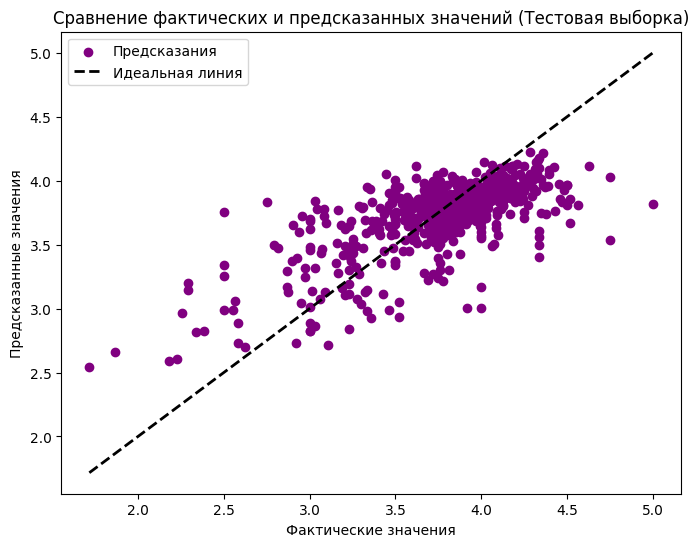

In [286]:
plot_scattering_diagram(y_test_reg_base, y_test_pred_reg_base)

## **3. Улучшение бейзлайна**

**a. b. c. Формирование гипотез и их проверка, а также формирование улучшенного бейзлайна по результатам проверки гипотез (препроцессинг данных, визуализация данных, формирование новых признаков, подбор гиперпараметров на кросс-валидации)**

### *Классификация*

**d. Обучение модели с улучшенным бейзлайном на выбранном наборе данных**

In [287]:
X_classification_optimized = df_flats_optimized.drop(columns=["Price", "Price Category"], axis=1)
y_classification_optimized = df_flats_optimized["Price Category"]

X_train_cls_optimized, X_test_cls_optimized, y_train_cls_optimized, y_test_cls_optimized = train_test_split(
    X_classification_optimized, y_classification_optimized, test_size=0.2, random_state=42
)


scaler = StandardScaler()
X_train_cls_scaled_optimized  = scaler.fit_transform(X_train_cls_optimized)
X_test_cls_scaled_optimized  = scaler.transform(X_test_cls_optimized)

rf_classifier = RandomForestClassifier(random_state=42)
rf_classifier.fit(X_train_cls_scaled_optimized, y_train_cls_optimized)

RandomForestClassifier(random_state=42)

**e.	Оценка качества моделей с улучшенным бейзлайном по выбранным метрикам на выбранных наборах данных**

In [288]:
y_pred_train_cls_optimized = rf_classifier.predict(X_train_cls_scaled_optimized)
y_pred_test_cls_optimized = rf_classifier.predict(X_test_cls_scaled_optimized)

evaluate_classification(y_test_cls_optimized, y_pred_test_cls_optimized, 'Оценка на валидационной выборке:')

print()

evaluate_classification(y_train_cls_optimized, y_pred_train_cls_optimized, 'Оценка на тренировочной выборке:')

Оценка на валидационной выборке:
Accuracy = 0.8842592592592593
Balanced accuracy = 0.8842586801697625

Оценка на тренировочной выборке:
Accuracy = 0.9942668136714443
Balanced accuracy = 0.9942787238059948


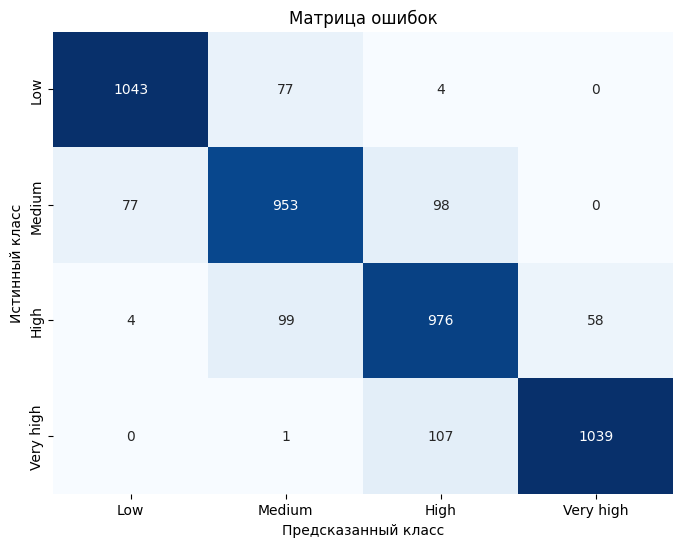

In [289]:
plot_confusion_matrix(y_test_cls_optimized, y_pred_test_cls_optimized)

**f.	Сравнить результаты моделей с улучшенным бейзлайном в сравнении с результатами из пункта 2**

После улучшения бейзлайна на валидационной выборке модель стала работать на 0.7% стало больше ошибок при классификации класса very high и hight

**g.	Сделать выводы**

В данном случае улучшение бейзлайна не помогло и гипотеза неверна. Модель на базовом бейзлайне работает не существенно, но лучше

### *Регрессия*

**d. Обучение модели с улучшенным бейзлайном на выбранном наборе данных**

In [290]:
X_regression_optimized = df_beer_optimized.drop(['review_overall'], axis=1)
y_regression_optimized = df_beer_optimized["review_overall"]
X_train_reg_optimized, X_test_reg_optimized, y_train_reg_optimized, y_test_reg_optimized = train_test_split(
    X_regression_optimized, y_regression_optimized, test_size=0.2, random_state=42
)


scaler = StandardScaler()
X_train_reg_scaled_optimized = scaler.fit_transform(X_train_reg_optimized)
X_test_reg_scaled_optimized = scaler.transform(X_test_reg_optimized)

rf_regressor = RandomForestRegressor(random_state=42)
rf_regressor.fit(X_train_reg_scaled_optimized, y_train_reg_optimized)

RandomForestRegressor(random_state=42)

**e.	Оценка качества моделей с улучшенным бейзлайном по выбранным метрикам на выбранных наборах данных**

In [291]:
y_test_pred_reg_optimized = rf_regressor.predict(X_test_reg_scaled_optimized)
y_train_pred_reg_optimized = rf_regressor.predict(X_train_reg_scaled_optimized)

evaluate_regression(y_test_reg_optimized, y_test_pred_reg_optimized, 'Оценка на валидационной выборке:')

print()

evaluate_regression(y_train_reg_optimized, y_train_pred_reg_optimized, 'Оценка на тренировочной выборке:')

Оценка на валидационной выборке:
MAE = 0.2265
MAPE = 6.3692%
MSE = 0.0915
RMSE = 0.3026

Оценка на тренировочной выборке:
MAE = 0.0839
MAPE = 2.3790%
MSE = 0.0130
RMSE = 0.1141


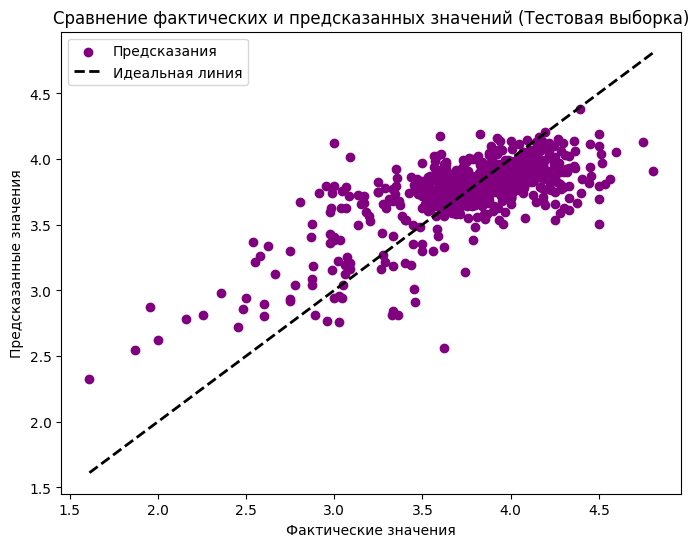

In [292]:
plot_scattering_diagram(y_test_reg_optimized, y_test_pred_reg_optimized)


**f.	Сравнить результаты моделей с улучшенным бейзлайном в сравнении с результатами из пункта 2**


MAE (Средняя абсолютная ошибка) уменьшилось на 0.007
MAPE (Средняя абсолютная процентная ошибка) уменьшилось на 0.17
MSE (Среднеквадратичная ошибка) уменьшилось на 0.013.
RMSE (Корень из MSE) снизился на 0.0055

**g.	Сделать выводы**

Модель на улучшенном бейзлайне немного лучше, но не существенно

## **4.	Имплементация алгоритма машинного обучения**

**a. Самостоятельно имплементировать алгоритмы машинного обучения (для классификации и регрессии)**

In [293]:
import numpy as np
from collections import Counter

def entropy(y):
    class_counts = Counter(y)
    probabilities = np.array(list(class_counts.values())) / len(y)
    return -np.sum(probabilities * np.log2(probabilities))

def gini_impurity(y):
    class_counts = Counter(y)
    probabilities = np.array(list(class_counts.values())) / len(y)
    return 1 - np.sum(probabilities ** 2)

def mean_squared_error(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

def best_split(X, y, criterion='gini'):
    best_impurity = float('inf')
    best_split_info = None
    n_samples, n_features = X.shape

    for feature_idx in range(n_features):
        possible_splits = np.unique(X[:, feature_idx])

        for threshold in possible_splits:
            left_mask = X[:, feature_idx] <= threshold
            right_mask = ~left_mask
            y_left, y_right = y[left_mask], y[right_mask]

            if len(y_left) == 0 or len(y_right) == 0:
                continue

            if criterion == 'gini':
                impurity = gini_impurity(y_left) * len(y_left) / n_samples + gini_impurity(y_right) * len(y_right) / n_samples
            elif criterion == 'entropy':
                impurity = entropy(y_left) * len(y_left) / n_samples + entropy(y_right) * len(y_right) / n_samples
            elif criterion == 'mse':
                left_pred = np.mean(y_left)
                right_pred = np.mean(y_right)
                impurity = (np.mean((y_left - left_pred) ** 2) * len(y_left) + np.mean((y_right - right_pred) ** 2) * len(y_right)) / n_samples
            else:
                raise ValueError("Criterion must be 'gini', 'entropy' or 'mse'")

            if impurity < best_impurity:
                best_impurity = impurity
                best_split_info = (feature_idx, threshold)

    return best_split_info

def build_tree(X, y, task='classification', max_depth=None, min_samples_split=2, depth=0, criterion='gini'):
    n_samples, n_features = X.shape
    unique_classes = np.unique(y)

    if len(unique_classes) == 1 or (max_depth and depth == max_depth) or n_samples < min_samples_split:
        if task == 'classification':
            return Counter(y).most_common(1)[0][0]
        elif task == 'regression':
            return np.mean(y)

    best_split_info = best_split(X, y, criterion)
    if not best_split_info:
        return np.mean(y) if task == 'regression' else Counter(y).most_common(1)[0][0]

    feature_idx, threshold = best_split_info
    left_mask = X[:, feature_idx] <= threshold
    right_mask = ~left_mask
    X_left, y_left = X[left_mask], y[left_mask]
    X_right, y_right = X[right_mask], y[right_mask]

    left_node = build_tree(X_left, y_left, task, max_depth, min_samples_split, depth+1, criterion)
    right_node = build_tree(X_right, y_right, task, max_depth, min_samples_split, depth+1, criterion)

    return (feature_idx, threshold, left_node, right_node)

def predict_tree(tree, X):
    if isinstance(tree, tuple):
        feature_idx, threshold, left_node, right_node = tree
        if X[feature_idx] <= threshold:
            return predict_tree(left_node, X)
        else:
            return predict_tree(right_node, X)
    else:
        return tree

def decision_tree(X_train, y_train, X_test, task='classification', max_depth=None, min_samples_split=2, criterion='gini'):
    tree = build_tree(X_train, y_train, task, max_depth, min_samples_split, criterion=criterion)
    y_pred = np.array([predict_tree(tree, x) for x in X_test])
    return y_pred

def random_forest(X_train, y_train, X_test, n_estimators=100, max_depth=None, min_samples_split=2, criterion='gini', task='classification', max_features=None):
    n_samples, n_features = X_train.shape
    predictions = []

    if max_features is None:
        max_features = n_features

    for _ in range(n_estimators):
        indices = np.random.choice(n_samples, size=n_samples, replace=True)
        X_bootstrap = X_train[indices]
        y_bootstrap = y_train.iloc[indices]

        features = np.random.choice(n_features, size=max_features, replace=False)
        X_bootstrap = X_bootstrap[:, features]

        tree = build_tree(X_bootstrap, y_bootstrap, task=task, max_depth=max_depth, min_samples_split=min_samples_split, criterion=criterion)

        X_test_selected_features = X_test[:, features]
        tree_preds = np.array([predict_tree(tree, x) for x in X_test_selected_features])
        predictions.append(tree_preds)

    predictions = np.array(predictions).T

    if task == 'classification':
        final_preds = [Counter(preds).most_common(1)[0][0] for preds in predictions]
    elif task == 'regression':
        final_preds = np.mean(predictions, axis=1)

    return np.array(final_preds)

#### *Классификация*

**b. Обучить имплементированную модель для выбранного набора данных**

In [294]:
y_pred_base = random_forest(X_train_cls_scaled_base, y_train_cls_base, X_test_cls_scaled_base, n_estimators=10, max_depth=5, min_samples_split=2, criterion='entropy', task='classification')

**c. Оценить качество имплементированной модели по выбранным метрикам на выбранном наборе данных**

In [295]:
evaluate_classification(y_test_cls_base, y_pred_base, 'Точность на валидационной выборке:')

Точность на валидационной выборке:
Accuracy = 0.8130511463844797
Balanced accuracy = 0.8130347142287759


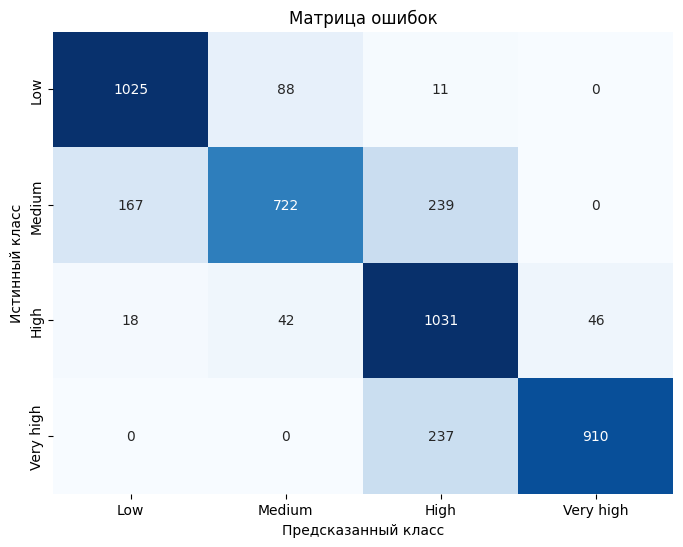

In [296]:
plot_confusion_matrix(y_test_cls_base, y_pred_base)

**d. Сравнить результаты имплементированных моделей в сравнении с результатами из пункта 2**

У собстевнной реализации точность меньше на 9% процентов

**e.	Сделать выводы**

Собстевенная имплементация проигрывает имплементации от sklearn

**f.	Добавить техники из улучшенного бейзлайна (пункт 3с)**

**g.	Обучить модели для выбранного набора данных**

In [297]:
y_pred_optimized = random_forest(X_train_cls_scaled_optimized, y_train_cls_optimized, X_test_cls_scaled_optimized, n_estimators=10, max_depth=10, criterion='gini', task='classification')

**h.	Оценить качество модели по выбранным метрикам на выбранном наборе данных**

In [298]:
evaluate_classification(y_test_cls_optimized, y_pred_optimized, 'Точность на валидационной выборке:')

Точность на валидационной выборке:
Accuracy = 0.8617724867724867
Balanced accuracy = 0.8618377490566764


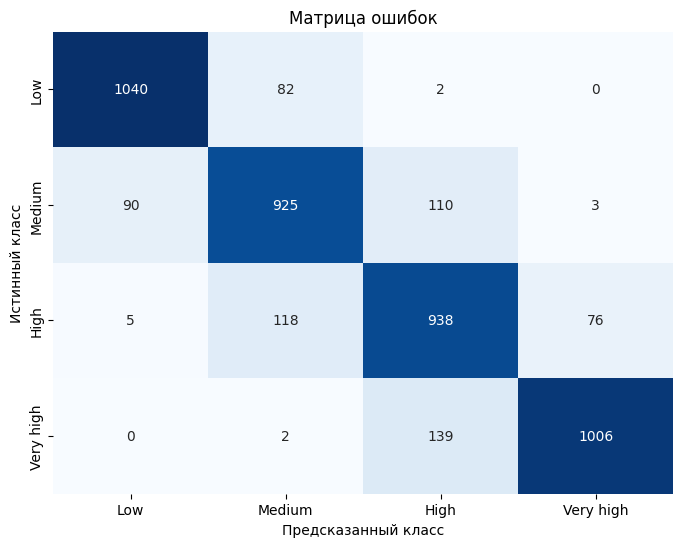

In [299]:
plot_confusion_matrix(y_test_cls_optimized, y_pred_optimized)

**i.	Сравнить результаты модели в сравнении с результатами из пункта 3**

Собственная реализация на улучшенном бейзлайне также проигрывает, хуже распознается левый нижний угол (см матрицу ошибок выше)

**j.	Сделать выводы**

Собственная реализация похуже

#### *Регрессия*

**b. Обучить имплементированную модель для выбранного набора данных**

In [300]:
y_pred_base = random_forest(X_train_reg_scaled_base, y_train_reg_base, X_test_reg_scaled_base, n_estimators=10, max_depth=10, criterion='mse', task='regression')

**c. Оценить качество имплементированной модели по выбранным метрикам на выбранном наборе данных**

In [301]:
evaluate_regression(y_test_reg_base, y_pred_base, 'Точность на валидационной выборке:')

Точность на валидационной выборке:
MAE = 0.2471
MAPE = 6.9360%
MSE = 0.1071
RMSE = 0.3272


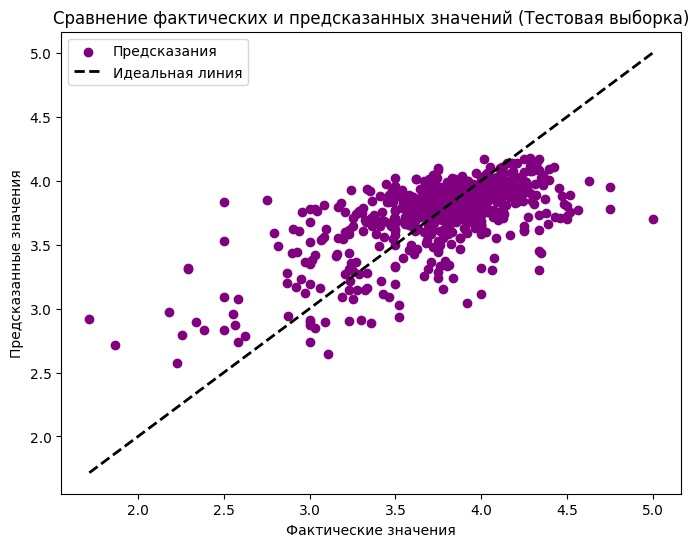

In [302]:
# Диаграмма рассеивания на тестовой выборке
plot_scattering_diagram(y_test_reg_base, y_pred_base)

**d. Сравнить результаты имплементированных моделей в сравнении с результатами из пункта 2**


MAE (Средняя абсолютная ошибка) увеличилась на 0.003
MAPE (Средняя абсолютная процентная ошибка) увеличилась на 0.11
MSE (Среднеквадратичная ошибка) уменьшилось на 0.001.
RMSE (Корень из MSE) снизился на 0.004

**e.	Сделать выводы**

Реализации моделей очень близки

**f.	Добавить техники из улучшенного бейзлайна (пункт 3с)**

**g.	Обучить модели для выбранного набора данных**

In [303]:
y_pred_optimized = random_forest(X_train_reg_scaled_optimized, y_train_reg_optimized, X_test_reg_scaled_optimized, n_estimators=10, max_depth=10, criterion='mse', task='regression')

**h.	Оценить качество модели по выбранным метрикам на выбранном наборе данных**

In [304]:
evaluate_regression(y_test_reg_optimized, y_pred_optimized, 'Точность на валидационной выборке:')

Точность на валидационной выборке:
MAE = 0.2361
MAPE = 6.6709%
MSE = 0.0992
RMSE = 0.3150


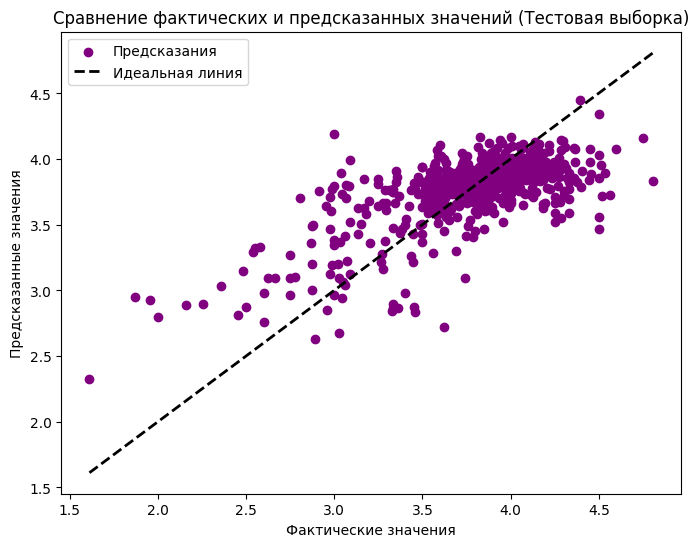

In [305]:
# Диаграмма рассеивания на тестовой выборке
plot_scattering_diagram(y_test_reg_optimized, y_pred_optimized)

**i.	Сравнить результаты модели в сравнении с результатами из пункта 3**


MAE (Средняя абсолютная ошибка) уменьшилось на 0.006
MAPE (Средняя абсолютная процентная ошибка) уменьшилось на 0.18
MSE (Среднеквадратичная ошибка) уменьшилось на 0.007.
RMSE (Корень из MSE) снизился на 0.005

**j.	Сделать выводы**

Реализации очень близки с друг другом, но собственная реализация работает похуже

# **Лабораторная работа 5**

# **Проведение исследований с градиентным бустингом**

## **2. Создание бейзлайна и оценка качества**

In [306]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, balanced_accuracy_score, mean_absolute_error, mean_squared_error
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor

### Классификация

#### **a. Обучение модели из sklearn для выбранного набора данных**

In [307]:
X_classification_base = df_flats_base.drop(["Price", "Price Category"], axis=1)
y_classification_base = df_flats_base["Price Category"]
X_train_cls_base, X_test_cls_base, y_train_cls_base, y_test_cls_base = train_test_split(
    X_classification_base, y_classification_base, test_size=0.2, random_state=42
)


scaler = StandardScaler()
X_train_cls_scaled_base = scaler.fit_transform(X_train_cls_base)
X_test_cls_scaled_base = scaler.transform(X_test_cls_base)

gb_classifier = GradientBoostingClassifier(random_state=42) 
gb_classifier.fit(X_train_cls_scaled_base, y_train_cls_base)

GradientBoostingClassifier(random_state=42)

#### **b. Оценка качества модели по выбранным метрикам на выбранном наборе данных**

In [308]:
y_test_pred_cls_base = gb_classifier.predict(X_test_cls_scaled_base)
y_train_pred_cls_base = gb_classifier.predict(X_train_cls_scaled_base)

evaluate_classification(y_test_cls_base, y_test_pred_cls_base, 'Оценка на валидационной выборке:')

print()

evaluate_classification(y_train_cls_base, y_train_pred_cls_base, 'Оценка на тренировочной выборке:')

Оценка на валидационной выборке:
Accuracy = 0.8597883597883598
Balanced accuracy = 0.8597899012712062

Оценка на тренировочной выборке:
Accuracy = 0.87348401323043
Balanced accuracy = 0.8735105437156409


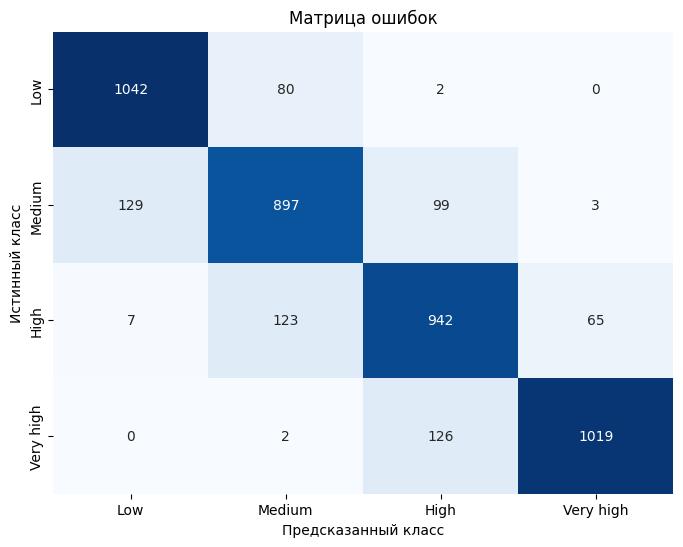

In [309]:
plot_confusion_matrix(y_test_cls_base, y_test_pred_cls_base)

In [310]:
null_accuracy_base = (y_test_cls_base.value_counts().max()/y_test_cls_base.value_counts().sum())
print('Null accuracy score: {0:0.4f}'. format(null_accuracy_base))

Null accuracy score: 0.2529


### *Регрессия*

#### **a. Обучение модели из sklearn для выбранного набора данных**

In [311]:
X_regression_base = df_beer_base.drop(['review_overall'], axis=1)
y_regression_base = df_beer_base["review_overall"]
X_train_reg_base, X_test_reg_base, y_train_reg_base, y_test_reg_base = train_test_split(
    X_regression_base, y_regression_base, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_reg_scaled_base = scaler.fit_transform(X_train_reg_base)
X_test_reg_scaled_base = scaler.transform(X_test_reg_base)

gb_regressor = GradientBoostingRegressor(random_state=42)
gb_regressor.fit(X_train_reg_scaled_base, y_train_reg_base)

GradientBoostingRegressor(random_state=42)

#### **b. Оценка качества модели по выбранным метрикам на выбранном наборе данных**

In [312]:
y_test_pred_reg_base = gb_regressor.predict(X_test_reg_scaled_base)
y_train_pred_reg_base = gb_regressor.predict(X_train_reg_scaled_base)

evaluate_regression(y_test_reg_base, y_test_pred_reg_base, 'Оценка на валидационной выборке:')

print()

evaluate_regression(y_train_reg_base, y_train_pred_reg_base, 'Оценка на тренировочной выборке:')

Оценка на валидационной выборке:
MAE = 0.2303
MAPE = 6.4567%
MSE = 0.0927
RMSE = 0.3044

Оценка на тренировочной выборке:
MAE = 0.1988
MAPE = 5.6746%
MSE = 0.0697
RMSE = 0.2640


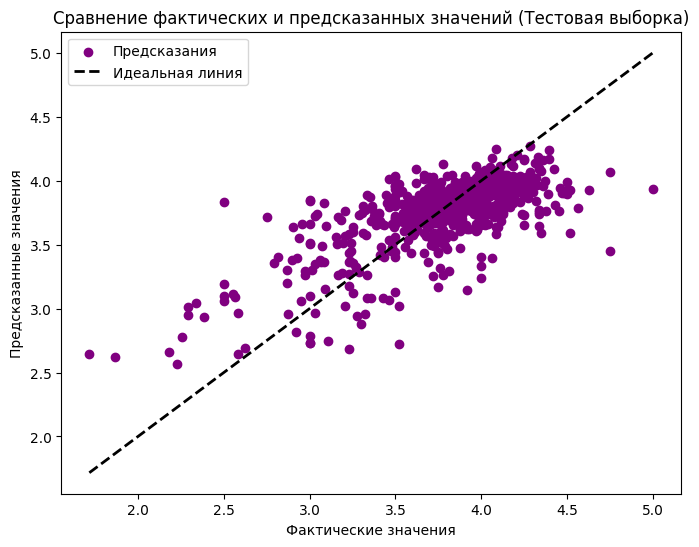

In [313]:
plot_scattering_diagram(y_test_reg_base, y_test_pred_reg_base)

## **3. Улучшение бейзлайна**

**a. b. c. Формирование гипотез и их проверка, а также формирование улучшенного бейзлайна по результатам проверки гипотез (препроцессинг данных, визуализация данных, формирование новых признаков, подбор гиперпараметров на кросс-валидации)**

### *Классификация*

**d. Обучение модели с улучшенным бейзлайном на выбранном наборе данных**

In [314]:
X_classification_optimized = df_flats_optimized.drop(columns=["Price Category", 'Price'], axis=1)
y_classification_optimized = df_flats_optimized["Price Category"]

X_train_cls_optimized, X_test_cls_optimized, y_train_cls_optimized, y_test_cls_optimized = train_test_split(
    X_classification_optimized, y_classification_optimized, test_size=0.2, random_state=42
)


scaler = StandardScaler()
X_train_cls_scaled_optimized  = scaler.fit_transform(X_train_cls_optimized)
X_test_cls_scaled_optimized  = scaler.transform(X_test_cls_optimized)

gb_classifier = GradientBoostingClassifier(random_state=42)  
gb_classifier.fit(X_train_cls_scaled_optimized, y_train_cls_optimized)

GradientBoostingClassifier(random_state=42)

**e.	Оценка качества моделей с улучшенным бейзлайном по выбранным метрикам на выбранных наборах данных**

In [315]:
y_pred_train_cls_optimized = gb_classifier.predict(X_train_cls_scaled_optimized)
y_pred_test_cls_optimized = gb_classifier.predict(X_test_cls_scaled_optimized)

evaluate_classification(y_test_cls_optimized, y_pred_test_cls_optimized, 'Оценка на валидационной выборке:')

print()

evaluate_classification(y_train_cls_optimized, y_pred_train_cls_optimized, 'Оценка на тренировочной выборке:')

Оценка на валидационной выборке:
Accuracy = 0.8562610229276896
Balanced accuracy = 0.8562573732247448

Оценка на тренировочной выборке:
Accuracy = 0.8756890848952591
Balanced accuracy = 0.8757113037700989


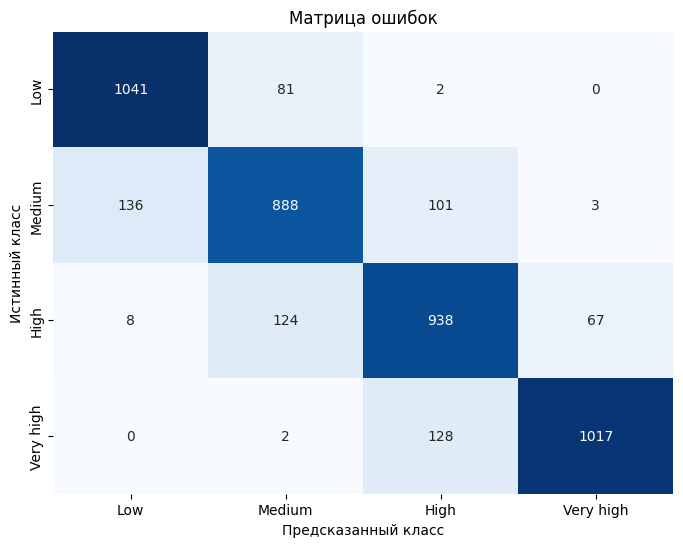

In [316]:
plot_confusion_matrix(y_test_cls_optimized, y_pred_test_cls_optimized)

**f.	Сравнить результаты моделей с улучшенным бейзлайном в сравнении с результатами из пункта 2**

После улучшения бейзлайна на валидационной выборке модель стала работать на 0.3% хуже

**g.	Сделать выводы**

Модель на улучшенном бейзлайне работает хуже, больше ошибок при классификации medium

### *Регрессия*

**d. Обучение модели с улучшенным бейзлайном на выбранном наборе данных**

In [317]:
X_regression_optimized = df_beer_optimized.drop(['review_overall'], axis=1)
y_regression_optimized = df_beer_optimized["review_overall"]
X_train_reg_optimized, X_test_reg_optimized, y_train_reg_optimized, y_test_reg_optimized = train_test_split(
    X_regression_optimized, y_regression_optimized, test_size=0.2, random_state=42
)


scaler = StandardScaler()
X_train_reg_scaled_optimized = scaler.fit_transform(X_train_reg_optimized)
X_test_reg_scaled_optimized = scaler.transform(X_test_reg_optimized)

gb_regressor = GradientBoostingRegressor(random_state=42)
gb_regressor.fit(X_train_reg_scaled_optimized, y_train_reg_optimized)

GradientBoostingRegressor(random_state=42)

**e.	Оценка качества моделей с улучшенным бейзлайном по выбранным метрикам на выбранных наборах данных**

In [318]:
y_test_pred_reg_optimized = gb_regressor.predict(X_test_reg_scaled_optimized)
y_train_pred_reg_optimized = gb_regressor.predict(X_train_reg_scaled_optimized)

evaluate_regression(y_test_reg_optimized, y_test_pred_reg_optimized, 'Оценка на валидационной выборке:')

print()

evaluate_regression(y_train_reg_optimized, y_train_pred_reg_optimized, 'Оценка на тренировочной выборке:')

Оценка на валидационной выборке:
MAE = 0.2325
MAPE = 6.5329%
MSE = 0.0947
RMSE = 0.3077

Оценка на тренировочной выборке:
MAE = 0.1968
MAPE = 5.5708%
MSE = 0.0682
RMSE = 0.2611


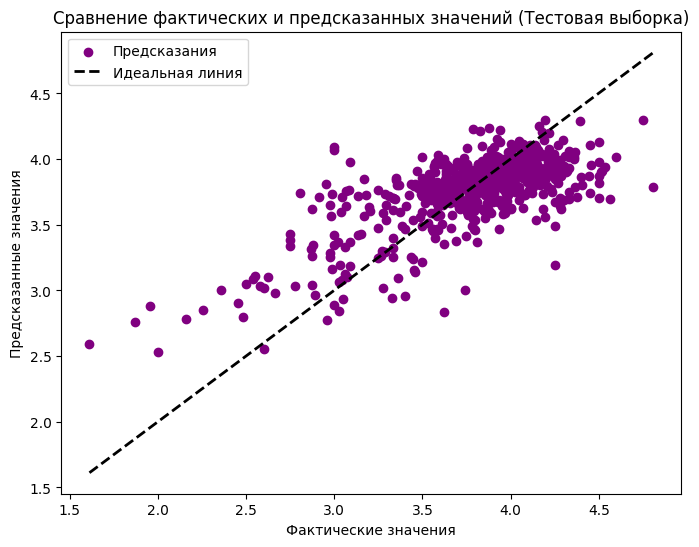

In [319]:
plot_scattering_diagram(y_test_reg_optimized, y_test_pred_reg_optimized)


**f.	Сравнить результаты моделей с улучшенным бейзлайном в сравнении с результатами из пункта 2**


MAE (Средняя абсолютная ошибка) уменьшилось на 0.001
MAPE (Средняя абсолютная процентная ошибка) уменьшилось на 0.08
MSE (Среднеквадратичная ошибка) уменьшилось на 0.001.
RMSE (Корень из MSE) снизился на 0.003

**g.	Сделать выводы**

В целом, результат можно считать одинаковые, разница метрик между базовым бейзлайном и улучшенным бейзлайном около 1e-4

## **4.	Имплементация алгоритма машинного обучения**

**a. Самостоятельно имплементировать алгоритмы машинного обучения (для классификации и регрессии)**

In [320]:
import numpy as np
from collections import Counter

def gradient_boosting(X_train, y_train, X_test, task='classification', n_estimators=100, learning_rate=0.1, max_depth=None, min_samples_split=2, criterion='gini'):
    if task == 'classification':
        class_map = {label: idx for idx, label in enumerate(np.unique(y_train))}
        y_train_num = np.array([class_map[label] for label in y_train])
    elif task == 'regression':
        y_train_num = np.array(y_train)
    else:
        raise ValueError("Task must be 'classification' or 'regression'")

    if task == 'classification':
        y_pred_train = np.full_like(y_train_num, np.mean(y_train_num), dtype=float)
        y_pred_test = np.full_like(np.zeros(X_test.shape[0]), np.mean(y_train_num), dtype=float)
    elif task == 'regression':
        y_pred_train = np.zeros_like(y_train_num, dtype=float)
        y_pred_test = np.zeros_like(np.zeros(X_test.shape[0]), dtype=float)

    trees = []

    for _ in range(n_estimators):
        residuals = y_train_num - y_pred_train
        tree = build_tree(X_train, residuals, task='regression', max_depth=max_depth, min_samples_split=min_samples_split, criterion='mse')
        trees.append(tree)

        for i, x in enumerate(X_train):
            y_pred_train[i] += learning_rate * predict_tree(tree, x)

        for i, x in enumerate(X_test):
            y_pred_test[i] += learning_rate * predict_tree(tree, x)

    if task == 'classification':
        y_pred_test_classes = np.round(y_pred_test).astype(int)
        reverse_class_map = {v: k for k, v in class_map.items()}
        y_pred_test_labels = [reverse_class_map[label] for label in y_pred_test_classes]
        return np.array(y_pred_test_labels)

    elif task == 'regression':
        return y_pred_test

#### *Классификация*

**b. Обучить имплементированную модель для выбранного набора данных**

In [321]:
y_pred_base = gradient_boosting(X_train_cls_scaled_base, y_train_cls_base, X_test_cls_scaled_base, task='classification', n_estimators=100, learning_rate=0.1)

**c. Оценить качество имплементированной модели по выбранным метрикам на выбранном наборе данных**

In [322]:
evaluate_classification(y_test_cls_base, y_pred_base, 'Точность на валидационной выборке:')

Точность на валидационной выборке:
Accuracy = 0.8454585537918872
Balanced accuracy = 0.845481366064164


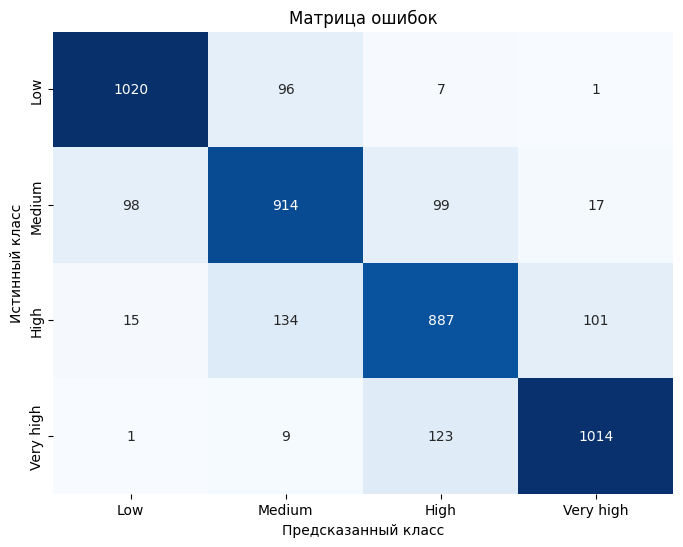

In [323]:
# Создание матрицы ошибок
plot_confusion_matrix(y_test_cls_base, y_pred_base)

**d. Сравнить результаты имплементированных моделей в сравнении с результатами из пункта 2**

Модели +- одинаковые. У моей реализации точность поменьше на 0.5%

**e.	Сделать выводы**

Модели отличаются точность на 0.5% процентов

**f.	Добавить техники из улучшенного бейзлайна (пункт 3с)**

Так как в основном всё что мне помогло - предобработка данных и её визуализация, повторять данную процедуру я не буду и просто обучу модель на уже улучшенных данных

**g.	Обучить модели для выбранного набора данных**

In [324]:
y_pred_optimized = gradient_boosting(X_train_cls_scaled_optimized, y_train_cls_optimized, X_test_cls_scaled_optimized, task='classification', n_estimators=100, learning_rate=0.1)

**h.	Оценить качество модели по выбранным метрикам на выбранном наборе данных**

In [325]:
evaluate_classification(y_test_cls_optimized, y_pred_optimized, 'Точность на валидационной выборке:')

Точность на валидационной выборке:
Accuracy = 0.8452380952380952
Balanced accuracy = 0.8452815858298406


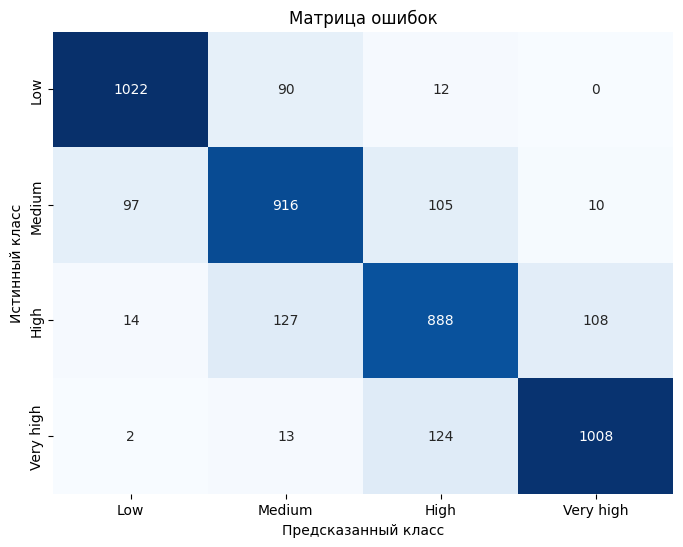

In [326]:
plot_confusion_matrix(y_test_cls_optimized, y_pred_optimized)

**i.	Сравнить результаты модели в сравнении с результатами из пункта 3**

Модели показали почти индентичный результат

**j.	Сделать выводы**

Собственная реализация работает примерно с той же точностью

#### *Регрессия*

**b. Обучить имплементированную модель для выбранного набора данных**

In [327]:
y_pred_base = gradient_boosting(X_train_reg_scaled_base, y_train_reg_base, X_test_reg_scaled_base, task='classification', n_estimators=100, learning_rate=0.1)

**c. Оценить качество имплементированной модели по выбранным метрикам на выбранном наборе данных**

In [328]:
evaluate_regression(y_test_reg_base, y_pred_base, 'Точность на валидационной выборке:')

Точность на валидационной выборке:
MAE = 0.3060
MAPE = 8.4770%
MSE = 0.1687
RMSE = 0.4107


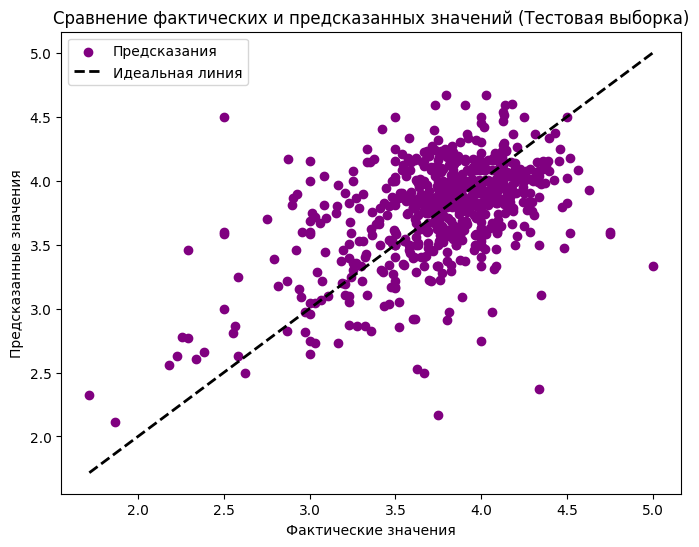

In [329]:
plot_scattering_diagram(y_test_reg_base, y_pred_base)

**d. Сравнить результаты имплементированных моделей в сравнении с результатами из пункта 2**

MAE (Средняя абсолютная ошибка) увеличилась на 0.07
MAPE (Средняя абсолютная процентная ошибка) увеличилась на 2
MSE (Среднеквадратичная ошибка) увеличилась на 0.07.
RMSE (Корень из MSE) увеличилась на 0.11

**e.	Сделать выводы**

Из метрик видно, что моя реализация будет похуже, но все равно обладает достаточно малой ошибкой

**f.	Добавить техники из улучшенного бейзлайна (пункт 3с)**

**g.	Обучить модели для выбранного набора данных**

In [330]:
y_pred_optimized = gradient_boosting(X_train_reg_scaled_optimized, y_train_reg_optimized, X_test_reg_scaled_optimized, task='classification', n_estimators=100, learning_rate=0.1)

**h.	Оценить качество модели по выбранным метрикам на выбранном наборе данных**

In [331]:
evaluate_regression(y_test_reg_optimized, y_pred_optimized, 'Точность на валидационной выборке:')

Точность на валидационной выборке:
MAE = 0.3201
MAPE = 8.8397%
MSE = 0.1789
RMSE = 0.4230


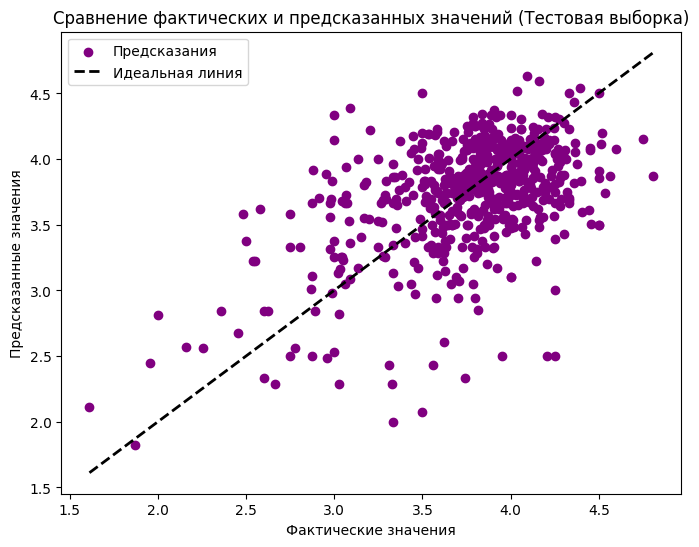

In [332]:
# Диаграмма рассеивания на тестовой выборке
plot_scattering_diagram(y_test_reg_optimized, y_pred_optimized)

**i.	Сравнить результаты модели в сравнении с результатами из пункта 3**

MAE (Средняя абсолютная ошибка) увеличилась на 0.08
MAPE (Средняя абсолютная процентная ошибка) увеличилась на 2.3
MSE (Среднеквадратичная ошибка) увеличилась на 0.08.
RMSE (Корень из MSE) увеличилась на 0.12

**j.	Сделать выводы**

Из метрик видно, что моя реализация будет похуже, но все равно обладает достаточно малой ошибкой

# Подведение итогов

## Классификация

|Алгоритм|  Бейзлайн  | Улучшенный бейзлайн | Самостоятельная имплементация алгоритм (СИА) | СИА с улучшенным бейзлайном |
|:------:|:----------:|:-------------------:|:------------------------------------------:|:----------------------------|
|KNN     |    0.84    |          0.8536            |                    0.8403                  | 0.838                       |
|Линейные модели|   07308    |       0.779       |                    0.7367                  |               0.807              |
|Решающее дерево|   0.8564   |        0.841         |                    **0.8573**           |              0.8487               |
|Случайный лес  | **0.8913** |     **0.8871**     |                    0.809                   |                 **0.8633**          |
|Градиентный бустинг|   0.8597   |       0.8562     |                     0.845                        |     0.845                        |


## Регрессия
|     Алгоритм      |          Бейзлайн           |     Улучшенный бейзлайн      | Самостоятельная имплементация алгоритма | СИА с улучшенным бейзлайном      |
|:-----------------:|:---------------------------:|:----------------------------:|:---------------------------------------:|:---------------------------------|
|     KNN           |           0.2709            |            0.2523            |                 0.2709                  | 0.2523                           | 
|  Линейные модели  |           0.2683            |           0.2747             |                 0.2683                  | 0.2751                           |
|  Решающее дерево  |           0.3167            |   0.3209  |                 0.3084                  | 0.3158                           |
|   Случайный лес   |           0.2336            | **0.2263** |                 **0.2379**                  | **0.2365**                         |
|Градиентный бустинг|          **0.2303**           |   0.2326   |       0.3060    | 0.3201                           | 
